In [1]:
# Cellule 1 — Import des bibliothèques nécessaires

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configuration affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ Bibliothèques importées avec succès")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")

✅ Bibliothèques importées avec succès
   pandas     : 2.3.3
   numpy      : 2.0.2


In [2]:
# Cellule 2 — Chargement du dataset

df = pd.read_csv('/kaggle/input/datasets/supriyoain/water-quality-data/waterquality.csv')

print("✅ Dataset chargé avec succès")
print("="*50)
print(f" Nombre de lignes    : {df.shape[0]}")
print(f" Nombre de colonnes  : {df.shape[1]}")
print("="*50)
print("\n📋 Nom des colonnes :")
for i, col in enumerate(df.columns, 1):
    print(f"   {i}. {col}")

✅ Dataset chargé avec succès
 Nombre de lignes    : 2371
 Nombre de colonnes  : 8

📋 Nom des colonnes :
   1. Date
   2. Salinity (ppt)
   3. DissolvedOxygen (mg/L)
   4. pH
   5. SecchiDepth (m)
   6. WaterDepth (m)
   7. WaterTemp (C)
   8. AirTemp (C)


In [3]:
# Cellule 3 — Aperçu visuel des premières et dernières lignes

print("🔍 PREMIÈRES 5 LIGNES :")
print("="*70)
print(df.head())

print("\n🔍 DERNIÈRES 5 LIGNES :")
print("="*70)
print(df.tail())

print("\n🔍 5 LIGNES ALÉATOIRES :")
print("="*70)
print(df.sample(5, random_state=42))

🔍 PREMIÈRES 5 LIGNES :
         Date  Salinity (ppt)  DissolvedOxygen (mg/L)    pH  SecchiDepth (m)  \
0  1989-05-11             NaN                     NaN 7.500            0.300   
1  1989-05-18             NaN                  12.000 7.500            0.200   
2  1989-05-25             NaN                     NaN 8.000            0.400   
3  1989-06-01             NaN                  12.000 8.000            0.400   
4  1989-07-11             NaN                     NaN 8.500            0.300   

   WaterDepth (m)  WaterTemp (C)  AirTemp (C)  
0           0.900         17.000      -17.778  
1           0.600         17.500       20.500  
2           0.800         23.000       25.000  
3           0.900         25.500       29.000  
4           0.900         28.500       28.000  

🔍 DERNIÈRES 5 LIGNES :
     Date  Salinity (ppt)  DissolvedOxygen (mg/L)    pH  SecchiDepth (m)  \
2366  NaN           0.000                     NaN 7.000            0.300   
2367  NaN             NaN       

In [4]:
# Cellule 4 — Types de données et valeurs manquantes

print("TYPES DE DONNÉES :")
print("="*50)
print(df.dtypes)

print("\n VALEURS MANQUANTES PAR COLONNE :")
print("="*50)
missing = pd.DataFrame({
    'Valeurs manquantes' : df.isnull().sum(),
    'Pourcentage (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

print("\n⚠️  LIGNES OÙ DATE EST MANQUANTE :")
print("="*50)
print(f"Nombre de lignes sans date : {df['Date'].isnull().sum()}")

print("\n⚠️  VALEUR SUSPECTE AirTemp = -17.778 :")
print("="*50)
print(f"Nombre d'occurrences : {(df['AirTemp (C)'] == -17.778).sum()}")

TYPES DE DONNÉES :
Date                       object
Salinity (ppt)            float64
DissolvedOxygen (mg/L)    float64
pH                        float64
SecchiDepth (m)           float64
WaterDepth (m)            float64
WaterTemp (C)             float64
AirTemp (C)               float64
dtype: object

 VALEURS MANQUANTES PAR COLONNE :
                        Valeurs manquantes  Pourcentage (%)
Date                                     5            0.210
Salinity (ppt)                         130            5.480
DissolvedOxygen (mg/L)                 851           35.890
pH                                      95            4.010
SecchiDepth (m)                         73            3.080
WaterDepth (m)                          71            2.990
WaterTemp (C)                          121            5.100
AirTemp (C)                              0            0.000

⚠️  LIGNES OÙ DATE EST MANQUANTE :
Nombre de lignes sans date : 5

⚠️  VALEUR SUSPECTE AirTemp = -17.778 :
Nombre d'occ

In [5]:
# Cellule 5 — Statistiques descriptives complètes

print("📊 STATISTIQUES DESCRIPTIVES :")
print("="*70)
print(df.describe().T)

print("\n  VÉRIFICATION VALEURS SUSPECTES AirTemp :")
print("="*70)
print(f"Valeur minimale AirTemp  : {df['AirTemp (C)'].min()}")
print(f"Valeur maximale AirTemp  : {df['AirTemp (C)'].max()}")
print(f"Nombre valeurs < -10°C   : {(df['AirTemp (C)'] < -10).sum()}")
print(f"Nombre valeurs > 50°C    : {(df['AirTemp (C)'] > 50).sum()}")

print("\n  VÉRIFICATION VALEURS SUSPECTES WaterTemp :")
print("="*70)
print(f"Valeur minimale WaterTemp : {df['WaterTemp (C)'].min()}")
print(f"Valeur maximale WaterTemp : {df['WaterTemp (C)'].max()}")
print(f"Nombre valeurs < 0°C      : {(df['WaterTemp (C)'] < 0).sum()}")
print(f"Nombre valeurs > 40°C     : {(df['WaterTemp (C)'] > 40).sum()}")

print("\n  VÉRIFICATION VALEURS SUSPECTES pH :")
print("="*70)
print(f"Valeur minimale pH : {df['pH'].min()}")
print(f"Valeur maximale pH : {df['pH'].max()}")
print(f"Nombre valeurs < 4 : {(df['pH'] < 4).sum()}")
print(f"Nombre valeurs > 11: {(df['pH'] > 11).sum()}")

print("\n  VÉRIFICATION VALEURS SUSPECTES DissolvedOxygen :")
print("="*70)
print(f"Valeur minimale DO : {df['DissolvedOxygen (mg/L)'].min()}")
print(f"Valeur maximale DO : {df['DissolvedOxygen (mg/L)'].max()}")
print(f"Nombre valeurs < 0 : {(df['DissolvedOxygen (mg/L)'] < 0).sum()}")
print(f"Nombre valeurs > 20: {(df['DissolvedOxygen (mg/L)'] > 20).sum()}")

📊 STATISTIQUES DESCRIPTIVES :
                          count   mean    std     min    25%    50%    75%  \
Salinity (ppt)         2241.000  0.717  1.231   0.000  0.000  0.000  1.000   
DissolvedOxygen (mg/L) 1520.000  6.646  2.507   0.000  4.800  6.500  8.500   
pH                     2276.000  7.168  0.788   0.300  6.500  7.000  7.500   
SecchiDepth (m)        2298.000  0.525  0.474   0.000  0.300  0.400  0.650   
WaterDepth (m)         2300.000  0.763  0.621   0.010  0.400  0.650  0.950   
WaterTemp (C)          2250.000 18.062  8.298   0.000 11.000 19.000 25.000   
AirTemp (C)            2371.000 15.663 10.315 -17.778  8.889 16.667 23.889   

                          max  
Salinity (ppt)          9.000  
DissolvedOxygen (mg/L) 15.100  
pH                      9.900  
SecchiDepth (m)         9.000  
WaterDepth (m)         12.000  
WaterTemp (C)          74.000  
AirTemp (C)            33.500  

  VÉRIFICATION VALEURS SUSPECTES AirTemp :
Valeur minimale AirTemp  : -17.77777778
Valeu

In [6]:
# Cellule 6 — Identification précise des anomalies détectées

print(" ANOMALIE 1 — WaterTemp > 40°C (physiquement impossible) :")
print("="*70)
print(df[df['WaterTemp (C)'] > 40][['Date', 'WaterTemp (C)', 'AirTemp (C)']])

print("\n ANOMALIE 2 — AirTemp < -10°C (suspect pour région côtière) :")
print("="*70)
print(f"Nombre total : {(df['AirTemp (C)'] < -10).sum()}")
print(df[df['AirTemp (C)'] < -10][['Date', 'AirTemp (C)']].head(10))

print("\n ANOMALIE 3 — pH < 4 (impossible en milieu naturel) :")
print("="*70)
print(df[df['pH'] < 4][['Date', 'pH']])

print("\n ANOMALIE 4 — SecchiDepth > 5m (très suspect pour eaux peu profondes) :")
print("="*70)
print(df[df['SecchiDepth (m)'] > 5][['Date', 'SecchiDepth (m)', 'WaterDepth (m)']])

print("\n ANOMALIE 5 — SecchiDepth > WaterDepth (physiquement impossible) :")
print("="*70)
mask = df['SecchiDepth (m)'] > df['WaterDepth (m)']
print(f"Nombre de cas : {mask.sum()}")
print(df[mask][['Date', 'SecchiDepth (m)', 'WaterDepth (m)']].head(10))

print("\n📋 RÉSUMÉ DES ANOMALIES DÉTECTÉES :")
print("="*70)
anomalies = {
    'WaterTemp > 40°C'        : (df['WaterTemp (C)'] > 40).sum(),
    'AirTemp < -10°C'         : (df['AirTemp (C)'] < -10).sum(),
    'pH < 4'                  : (df['pH'] < 4).sum(),
    'SecchiDepth > WaterDepth': (df['SecchiDepth (m)'] > df['WaterDepth (m)']).sum(),
    'Date manquante'          : df['Date'].isnull().sum(),
    'DO manquant (35.89%)'    : df['DissolvedOxygen (mg/L)'].isnull().sum(),
}
for k, v in anomalies.items():
    print(f"     {k:<30} → {v} cas")

 ANOMALIE 1 — WaterTemp > 40°C (physiquement impossible) :
            Date  WaterTemp (C)  AirTemp (C)
370   1999-10-27         43.000       22.222
372   1999-10-27         42.500       22.222
622   2002-01-22         59.000        9.944
715   2002-12-06         48.000        3.333
831   2004-02-05         60.000        6.111
1013  2005-09-08         74.000       24.444
1164  2007-01-04         54.000      -11.111

 ANOMALIE 2 — AirTemp < -10°C (suspect pour région côtière) :
Nombre total : 74
           Date  AirTemp (C)
0    1989-05-11      -17.778
44   1990-07-16      -17.778
282  1996-08-02      -17.778
283  1996-08-11      -17.778
284  1996-08-18      -17.778
285  1996-09-01      -17.778
286  1996-09-15      -17.778
287  1996-09-22      -17.778
288  1996-09-28      -17.778
300  1997-01-19      -17.778

 ANOMALIE 3 — pH < 4 (impossible en milieu naturel) :
           Date    pH
579  2001-09-05 0.300
910  2004-10-01 0.700

 ANOMALIE 4 — SecchiDepth > 5m (très suspect pour eaux peu 

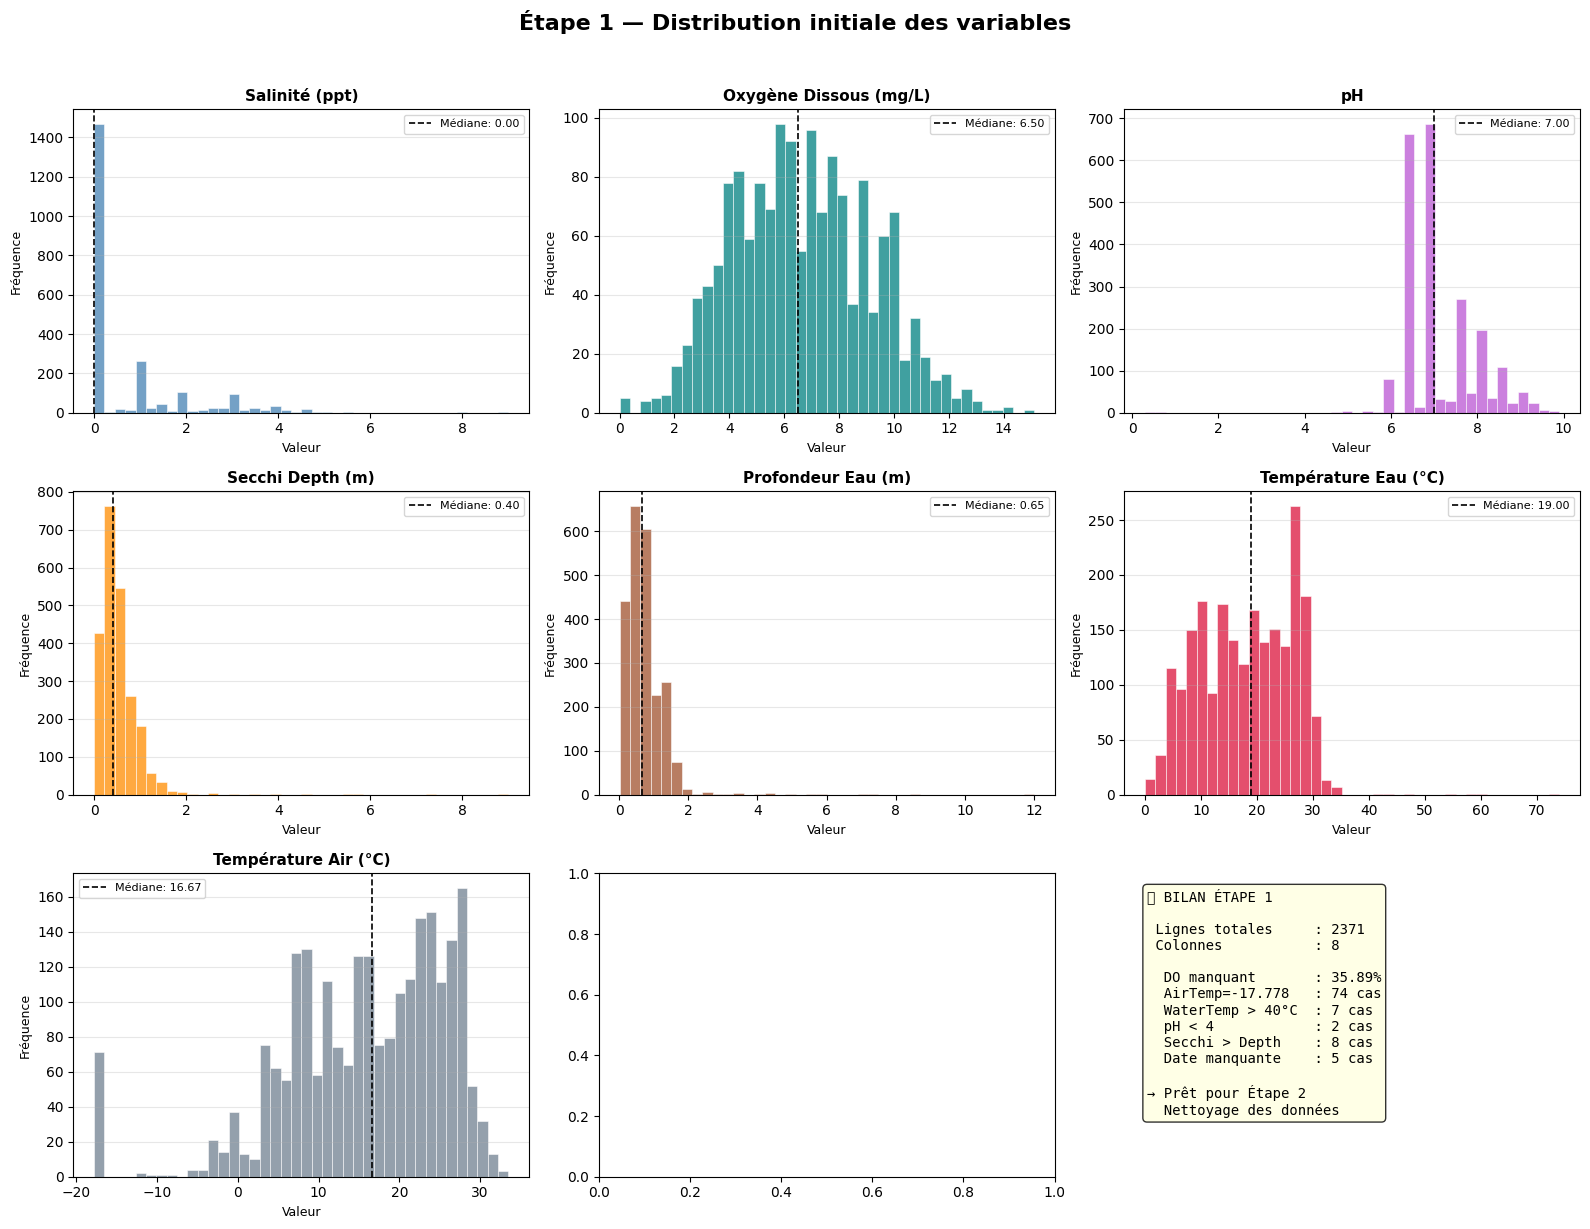


 Étape 1 terminée — Bilan complet des anomalies identifiées
   Problème majeur  : DO manquant à 35.89% → traitement spécial
   Valeurs codées   : AirTemp=-17.778 → remplacer par NaN
   Valeurs physiques: WaterTemp=74°C, pH=0.3 → supprimer
   Incohérences     : SecchiDepth > WaterDepth → corriger


In [7]:
# Cellule 7 — Visualisation exploratoire initiale

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Étape 1 — Distribution initiale des variables', fontsize=16, fontweight='bold', y=1.02)

variables = [
    ('Salinity (ppt)',          'Salinité (ppt)',            'steelblue'),
    ('DissolvedOxygen (mg/L)',  'Oxygène Dissous (mg/L)',    'teal'),
    ('pH',                      'pH',                        'mediumorchid'),
    ('SecchiDepth (m)',         'Secchi Depth (m)',           'darkorange'),
    ('WaterDepth (m)',          'Profondeur Eau (m)',         'sienna'),
    ('WaterTemp (C)',           'Température Eau (°C)',       'crimson'),
    ('AirTemp (C)',             'Température Air (°C)',       'slategray'),
]

for idx, (col, label, color) in enumerate(variables):
    row, col_idx = divmod(idx, 3)
    ax = axes[row][col_idx]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur', fontsize=9)
    ax.set_ylabel('Fréquence', fontsize=9)
    
    # Ligne médiane
    median_val = data.median()
    ax.axvline(median_val, color='black', linestyle='--', linewidth=1.2, label=f'Médiane: {median_val:.2f}')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

# Résumé anomalies dans la dernière case
ax_summary = axes[2][2]
ax_summary.axis('off')
summary_text = (
    "📋 BILAN ÉTAPE 1\n\n"
    f" Lignes totales     : 2371\n"
    f" Colonnes           : 8\n\n"
    f"  DO manquant       : 35.89%\n"
    f"  AirTemp=-17.778   : 74 cas\n"
    f"  WaterTemp > 40°C  : 7 cas\n"
    f"  pH < 4            : 2 cas\n"
    f"  Secchi > Depth    : 8 cas\n"
    f"  Date manquante    : 5 cas\n\n"
    f"→ Prêt pour Étape 2\n"
    f"  Nettoyage des données"
)
ax_summary.text(0.05, 0.95, summary_text, transform=ax_summary.transAxes,
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('etape1_distribution_initiale.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Étape 1 terminée — Bilan complet des anomalies identifiées")
print("="*60)
print("   Problème majeur  : DO manquant à 35.89% → traitement spécial")
print("   Valeurs codées   : AirTemp=-17.778 → remplacer par NaN")
print("   Valeurs physiques: WaterTemp=74°C, pH=0.3 → supprimer")
print("   Incohérences     : SecchiDepth > WaterDepth → corriger")


In [8]:
# Étape 2 — Cellule 1 : Remplacement des valeurs codées et physiquement impossibles

df_clean = df.copy()

print("🔧 TRAITEMENT 1 — AirTemp = -17.778 → NaN (valeur codée manquante)")
print("="*60)
before = (df_clean['AirTemp (C)'] == -17.778).sum()
df_clean['AirTemp (C)'] = df_clean['AirTemp (C)'].replace(-17.778, np.nan)
after = (df_clean['AirTemp (C)'] == -17.778).sum()
print(f"   Avant : {before} cas  →  Après : {after} cas ")

print("\n🔧 TRAITEMENT 2 — WaterTemp > 40°C → NaN (physiquement impossible)")
print("="*60)
before = (df_clean['WaterTemp (C)'] > 40).sum()
df_clean.loc[df_clean['WaterTemp (C)'] > 40, 'WaterTemp (C)'] = np.nan
after = (df_clean['WaterTemp (C)'] > 40).sum()
print(f"   Avant : {before} cas  →  Après : {after} cas ")

print("\n🔧 TRAITEMENT 3 — pH < 4 → NaN (physiquement impossible)")
print("="*60)
before = (df_clean['pH'] < 4).sum()
df_clean.loc[df_clean['pH'] < 4, 'pH'] = np.nan
after = (df_clean['pH'] < 4).sum()
print(f"   Avant : {before} cas  →  Après : {after} cas ")

print("\n🔧 TRAITEMENT 4 — SecchiDepth > WaterDepth → NaN (incohérence physique)")
print("="*60)
mask = df_clean['SecchiDepth (m)'] > df_clean['WaterDepth (m)']
before = mask.sum()
df_clean.loc[mask, 'SecchiDepth (m)'] = np.nan
after = (df_clean['SecchiDepth (m)'] > df_clean['WaterDepth (m)']).sum()
print(f"   Avant : {before} cas  →  Après : {after} cas ")

print("\n🔧 TRAITEMENT 5 — Lignes sans Date → suppression")
print("="*60)
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Date'])
after = len(df_clean)
print(f"   Avant : {before} lignes  →  Après : {after} lignes ")

print("\n📋 NOUVELLES VALEURS MANQUANTES APRÈS TRAITEMENT :")
print("="*60)
missing = pd.DataFrame({
    'Valeurs manquantes' : df_clean.isnull().sum(),
    'Pourcentage (%)' : (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})
print(missing)

🔧 TRAITEMENT 1 — AirTemp = -17.778 → NaN (valeur codée manquante)
   Avant : 0 cas  →  Après : 0 cas 

🔧 TRAITEMENT 2 — WaterTemp > 40°C → NaN (physiquement impossible)
   Avant : 7 cas  →  Après : 0 cas 

🔧 TRAITEMENT 3 — pH < 4 → NaN (physiquement impossible)
   Avant : 2 cas  →  Après : 0 cas 

🔧 TRAITEMENT 4 — SecchiDepth > WaterDepth → NaN (incohérence physique)
   Avant : 8 cas  →  Après : 0 cas 

🔧 TRAITEMENT 5 — Lignes sans Date → suppression
   Avant : 2371 lignes  →  Après : 2366 lignes 

📋 NOUVELLES VALEURS MANQUANTES APRÈS TRAITEMENT :
                        Valeurs manquantes  Pourcentage (%)
Date                                     0            0.000
Salinity (ppt)                         129            5.450
DissolvedOxygen (mg/L)                 847           35.800
pH                                      95            4.020
SecchiDepth (m)                         79            3.340
WaterDepth (m)                          69            2.920
WaterTemp (C)             

In [9]:
# Étape 2 — Cellule 2 : Correction AirTemp et vérification approfondie

print("VÉRIFICATION AirTemp — valeurs < -10°C encore présentes :")
print("="*60)
print(df_clean[df_clean['AirTemp (C)'] < -10][['Date', 'AirTemp (C)']].head(10))
print(f"\nNombre total : {(df_clean['AirTemp (C)'] < -10).sum()}")

print("\n🔧 CORRECTION — Remplacement AirTemp < -10°C par NaN")
print("="*60)
before = (df_clean['AirTemp (C)'] < -10).sum()
df_clean.loc[df_clean['AirTemp (C)'] < -10, 'AirTemp (C)'] = np.nan
after = (df_clean['AirTemp (C)'] < -10).sum()
print(f"   Avant : {before} cas  →  Après : {after} cas ")

print("\n VÉRIFICATION FINALE — Plages physiques de toutes les variables :")
print("="*60)
checks = {
    'Salinity (ppt)'        : (0, 45),
    'DissolvedOxygen (mg/L)': (0, 20),
    'pH'                    : (4, 11),
    'SecchiDepth (m)'       : (0, 15),
    'WaterDepth (m)'        : (0, 20),
    'WaterTemp (C)'         : (0, 40),
    'AirTemp (C)'           : (-10, 50),
}

all_ok = True
for col, (vmin, vmax) in checks.items():
    n_below = (df_clean[col] < vmin).sum()
    n_above = (df_clean[col] > vmax).sum()
    status = "" if (n_below == 0 and n_above == 0) else "⚠️ "
    if status == "⚠️ ":
        all_ok = False
    print(f"   {status} {col:<30} [{vmin} – {vmax}]  "
          f"| < min: {n_below}  | > max: {n_above}")

print("\n" + "="*60)
if all_ok:
    print(" Toutes les variables sont dans leurs plages physiques valides")
else:
    print("  Des anomalies subsistent — vérification nécessaire")

print(f"\n📊 Dimensions actuelles du dataset : {df_clean.shape}")

VÉRIFICATION AirTemp — valeurs < -10°C encore présentes :
           Date  AirTemp (C)
0    1989-05-11      -17.778
44   1990-07-16      -17.778
282  1996-08-02      -17.778
283  1996-08-11      -17.778
284  1996-08-18      -17.778
285  1996-09-01      -17.778
286  1996-09-15      -17.778
287  1996-09-22      -17.778
288  1996-09-28      -17.778
300  1997-01-19      -17.778

Nombre total : 72

🔧 CORRECTION — Remplacement AirTemp < -10°C par NaN
   Avant : 72 cas  →  Après : 0 cas 

 VÉRIFICATION FINALE — Plages physiques de toutes les variables :
    Salinity (ppt)                 [0 – 45]  | < min: 0  | > max: 0
    DissolvedOxygen (mg/L)         [0 – 20]  | < min: 0  | > max: 0
    pH                             [4 – 11]  | < min: 0  | > max: 0
    SecchiDepth (m)                [0 – 15]  | < min: 0  | > max: 0
    WaterDepth (m)                 [0 – 20]  | < min: 0  | > max: 0
    WaterTemp (C)                  [0 – 40]  | < min: 0  | > max: 0
    AirTemp (C)                    [-10

In [10]:
# Étape 2 — Cellule 3 : Imputation des valeurs manquantes

from sklearn.impute import KNNImputer

print("📋 VALEURS MANQUANTES AVANT IMPUTATION :")
print("="*60)
missing_before = df_clean.isnull().sum()
for col, val in missing_before.items():
    if col != 'Date' and val > 0:
        pct = val / len(df_clean) * 100
        print(f"    {col:<30} : {val} ({pct:.2f}%)")

# Colonnes numériques à imputer
num_cols = [
    'Salinity (ppt)',
    'DissolvedOxygen (mg/L)',
    'pH',
    'SecchiDepth (m)',
    'WaterDepth (m)',
    'WaterTemp (C)',
    'AirTemp (C)'
]

print("\n🔧 APPLICATION KNN IMPUTER (k=5) :")
print("="*60)
print("   Stratégie : KNN utilise les 5 voisins les plus proches")
print("   Avantage  : respecte les relations entre variables")
print("   Cas DO    : 35.80% manquant → imputation basée sur")
print("               Température + pH + Salinité (corrélés)")

imputer = KNNImputer(n_neighbors=5)
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

print("\n VALEURS MANQUANTES APRÈS IMPUTATION :")
print("="*60)
missing_after = df_clean[num_cols].isnull().sum()
all_zero = True
for col in num_cols:
    val = missing_after[col]
    status = "✅" if val == 0 else "⚠️ "
    if val > 0:
        all_zero = False
    print(f"   {status} {col:<30} : {val}")

print("\n" + "="*60)
if all_zero:
    print(" Toutes les valeurs manquantes ont été imputées")
else:
    print("  Des valeurs manquantes subsistent")

print(f"\n Statistiques après imputation :")
print("="*60)
print(df_clean[num_cols].describe().T[['mean','std','min','max']].round(3))

📋 VALEURS MANQUANTES AVANT IMPUTATION :
    Salinity (ppt)                 : 129 (5.45%)
    DissolvedOxygen (mg/L)         : 847 (35.80%)
    pH                             : 95 (4.02%)
    SecchiDepth (m)                : 79 (3.34%)
    WaterDepth (m)                 : 69 (2.92%)
    WaterTemp (C)                  : 126 (5.33%)
    AirTemp (C)                    : 72 (3.04%)

🔧 APPLICATION KNN IMPUTER (k=5) :
   Stratégie : KNN utilise les 5 voisins les plus proches
   Avantage  : respecte les relations entre variables
   Cas DO    : 35.80% manquant → imputation basée sur
               Température + pH + Salinité (corrélés)

 VALEURS MANQUANTES APRÈS IMPUTATION :
   ✅ Salinity (ppt)                 : 0
   ✅ DissolvedOxygen (mg/L)         : 0
   ✅ pH                             : 0
   ✅ SecchiDepth (m)                : 0
   ✅ WaterDepth (m)                 : 0
   ✅ WaterTemp (C)                  : 0
   ✅ AirTemp (C)                    : 0

 Toutes les valeurs manquantes ont été imput

In [11]:
# Étape 2 — Cellule 4 : Conversion Date et tri chronologique

print("🔧 CONVERSION DE LA COLONNE DATE :")
print("="*60)
print(f"   Type avant : {df_clean['Date'].dtype}")

df_clean['Date'] = pd.to_datetime(df_clean['Date'])

print(f"   Type après : {df_clean['Date'].dtype} ")

# Tri chronologique
df_clean = df_clean.sort_values('Date').reset_index(drop=True)

print("\n INFORMATIONS TEMPORELLES :")
print("="*60)
print(f"   Date de début  : {df_clean['Date'].min().date()}")
print(f"   Date de fin    : {df_clean['Date'].max().date()}")
print(f"   Durée totale   : {(df_clean['Date'].max() - df_clean['Date'].min()).days} jours")
print(f"   Années couvertes : {df_clean['Date'].dt.year.nunique()} ans "
      f"({df_clean['Date'].dt.year.min()} → {df_clean['Date'].dt.year.max()})")

print("\n EXTRACTION DES COMPOSANTES TEMPORELLES :")
print("="*60)
df_clean['Year']    = df_clean['Date'].dt.year
df_clean['Month']   = df_clean['Date'].dt.month
df_clean['Season']  = df_clean['Month'].map({
    12: 'Hiver', 1: 'Hiver',  2: 'Hiver',
    3 : 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6 : 'Été',   7: 'Été',    8: 'Été',
    9 : 'Automne', 10: 'Automne', 11: 'Automne'
})

print("    Colonne Year    créée")
print("    Colonne Month   créée")
print("    Colonne Season  créée")

print("\n DISTRIBUTION PAR SAISON :")
print("="*60)
saison_counts = df_clean['Season'].value_counts()
for saison, count in saison_counts.items():
    pct = count / len(df_clean) * 100
    bar = '█' * int(pct / 2)
    print(f"   {saison:<12} : {count:>4} observations ({pct:.1f}%) {bar}")

print("\n📅 DISTRIBUTION PAR ANNÉE (aperçu) :")
print("="*60)
year_counts = df_clean['Year'].value_counts().sort_index()
print(f"   Min observations/an : {year_counts.min()} "
      f"(année {year_counts.idxmin()})")
print(f"   Max observations/an : {year_counts.max()} "
      f"(année {year_counts.idxmax()})")
print(f"   Moy observations/an : {year_counts.mean():.1f}")

print(f"\n📊 Dimensions actuelles : {df_clean.shape}")

🔧 CONVERSION DE LA COLONNE DATE :
   Type avant : object
   Type après : datetime64[ns] 

 INFORMATIONS TEMPORELLES :
   Date de début  : 1989-05-11
   Date de fin    : 2019-11-05
   Durée totale   : 11135 jours
   Années couvertes : 31 ans (1989 → 2019)

 EXTRACTION DES COMPOSANTES TEMPORELLES :
    Colonne Year    créée
    Colonne Month   créée
    Colonne Season  créée

 DISTRIBUTION PAR SAISON :
   Automne      :  614 observations (26.0%) ████████████
   Printemps    :  608 observations (25.7%) ████████████
   Été          :  594 observations (25.1%) ████████████
   Hiver        :  550 observations (23.2%) ███████████

📅 DISTRIBUTION PAR ANNÉE (aperçu) :
   Min observations/an : 15 (année 1998)
   Max observations/an : 120 (année 2009)
   Moy observations/an : 76.3

📊 Dimensions actuelles : (2366, 11)


In [13]:
# Étape 2 — Cellule 5 : Vérification finale et sauvegarde

print(" VÉRIFICATION FINALE DU DATASET NETTOYÉ :")
print("="*60)

# Dimensions
print(f"\n Dimensions   : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes")

# Valeurs manquantes
total_missing = df_clean.isnull().sum().sum()
print(f" Valeurs manquantes totales : {total_missing}")

# Types
print(f"\n📋 Types de données :")
for col, dtype in df_clean.dtypes.items():
    print(f"   {col:<30} : {dtype}")

# Plages finales
print(f"\n STATISTIQUES FINALES :")
print("="*60)
num_cols = [
    'Salinity (ppt)', 'DissolvedOxygen (mg/L)', 'pH',
    'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)'
]
print(df_clean[num_cols].describe().T[['mean','std','min','max']].round(3))

# Comparaison avant/après nettoyage
print(f"\n BILAN COMPARATIF AVANT / APRÈS NETTOYAGE :")
print("="*60)
bilan = {
    'Lignes totales'         : (2371,          df_clean.shape[0]),
    'Valeurs manquantes'     : (2371,           total_missing),
    'WaterTemp > 40°C'       : (7,              0),
    'AirTemp < -10°C'        : (74,             0),
    'pH < 4'                 : (2,              0),
    'SecchiDepth > WaterDepth': (8,             0),
    'Date manquante'         : (5,              0),
}
print(f"   {'Indicateur':<28} {'Avant':>8}  {'Après':>8}  Statut")
print("   " + "-"*52)
for indicateur, (avant, apres) in bilan.items():
    status = "✅" if apres == 0 or apres < avant else "➡️"
    print(f"   {indicateur:<28} {avant:>8}  {apres:>8}  {status}")

# Sauvegarde
df_clean.to_csv('water_quality_clean.csv', index=False)
print(f"\n Dataset sauvegardé → water_quality_clean.csv")
print("="*60)


 VÉRIFICATION FINALE DU DATASET NETTOYÉ :

 Dimensions   : 2366 lignes × 11 colonnes
 Valeurs manquantes totales : 0

📋 Types de données :
   Date                           : datetime64[ns]
   Salinity (ppt)                 : float64
   DissolvedOxygen (mg/L)         : float64
   pH                             : float64
   SecchiDepth (m)                : float64
   WaterDepth (m)                 : float64
   WaterTemp (C)                  : float64
   AirTemp (C)                    : float64
   Year                           : int32
   Month                          : int32
   Season                         : object

 STATISTIQUES FINALES :
                         mean   std    min    max
Salinity (ppt)          0.726 1.211  0.000  9.000
DissolvedOxygen (mg/L)  6.421 2.244  0.000 15.100
pH                      7.178 0.757  4.800  9.900
SecchiDepth (m)         0.522 0.462  0.000  9.000
WaterDepth (m)          0.762 0.615  0.010 12.000
WaterTemp (C)          18.007 7.960  0.000 35.000


In [14]:
# Étape 3 — Cellule 1 : Définition des seuils officiels WQI
# Références : OMS (2022) · EPA (2024) · EU BWD (2006/7/EC) · UNEP/MAP (2023)

print(" SEUILS OFFICIELS PAR VARIABLE — RÉFÉRENCES MONDIALES :")
print("="*70)

# ── Seuils par variable ──────────────────────────────────────────────────────
seuils = {
    'pH' : {
        'Excellente' : (7.5,  8.3),
        'Bonne'      : (6.5,  8.5),
        'Acceptable' : (6.0,  9.0),
        'Mauvaise'   : (5.5,  9.5),
        'Dangereuse' : (0,    14 ),
        'ref'        : 'OMS (2022) · EPA (2024)'
    },
    'DissolvedOxygen (mg/L)' : {
        'Excellente' : (8.0,  20 ),
        'Bonne'      : (6.0,  20 ),
        'Acceptable' : (5.0,  20 ),
        'Mauvaise'   : (3.0,  20 ),
        'Dangereuse' : (0,    20 ),
        'ref'        : 'EPA (2024) · FAO (2015)'
    },
    'Salinity (ppt)' : {
        'Excellente' : (0.0,  0.5),   # eau douce/saumâtre locale
        'Bonne'      : (0.0,  2.0),
        'Acceptable' : (0.0,  4.0),
        'Mauvaise'   : (0.0,  7.0),
        'Dangereuse' : (0.0,  9.0),
        'ref'        : 'IOC-UNESCO (2010) · FAO (2015)'
    },
    'WaterTemp (C)' : {
        'Excellente' : (15,   25 ),
        'Bonne'      : (10,   28 ),
        'Acceptable' : (5,    30 ),
        'Mauvaise'   : (2,    35 ),
        'Dangereuse' : (0,    40 ),
        'ref'        : 'EU BWD (2006) · UNEP/MAP (2023)'
    },
    'SecchiDepth (m)' : {
        'Excellente' : (2.0,  99 ),
        'Bonne'      : (1.0,  99 ),
        'Acceptable' : (0.5,  99 ),
        'Mauvaise'   : (0.2,  99 ),
        'Dangereuse' : (0.0,  99 ),
        'ref'        : 'EU WFD (2000) · HELCOM (2023)'
    },
}

# Poids officiels OMS/EPA
poids = {
    'DissolvedOxygen (mg/L)' : 0.30,
    'pH'                     : 0.25,
    'Salinity (ppt)'         : 0.20,
    'WaterTemp (C)'          : 0.15,
    'SecchiDepth (m)'        : 0.10,
}

for var, info in seuils.items():
    print(f"\n    {var}")
    print(f"      Référence   : {info['ref']}")
    print(f"      Poids WQI   : {poids.get(var, 'N/A')}")
    print(f"      Excellente  : {info['Excellente']}")
    print(f"      Bonne       : {info['Bonne']}")
    print(f"      Acceptable  : {info['Acceptable']}")
    print(f"      Mauvaise    : {info['Mauvaise']}")
    print(f"      Dangereuse  : {info['Dangereuse']}")


 SEUILS OFFICIELS PAR VARIABLE — RÉFÉRENCES MONDIALES :

    pH
      Référence   : OMS (2022) · EPA (2024)
      Poids WQI   : 0.25
      Excellente  : (7.5, 8.3)
      Bonne       : (6.5, 8.5)
      Acceptable  : (6.0, 9.0)
      Mauvaise    : (5.5, 9.5)
      Dangereuse  : (0, 14)

    DissolvedOxygen (mg/L)
      Référence   : EPA (2024) · FAO (2015)
      Poids WQI   : 0.3
      Excellente  : (8.0, 20)
      Bonne       : (6.0, 20)
      Acceptable  : (5.0, 20)
      Mauvaise    : (3.0, 20)
      Dangereuse  : (0, 20)

    Salinity (ppt)
      Référence   : IOC-UNESCO (2010) · FAO (2015)
      Poids WQI   : 0.2
      Excellente  : (0.0, 0.5)
      Bonne       : (0.0, 2.0)
      Acceptable  : (0.0, 4.0)
      Mauvaise    : (0.0, 7.0)
      Dangereuse  : (0.0, 9.0)

    WaterTemp (C)
      Référence   : EU BWD (2006) · UNEP/MAP (2023)
      Poids WQI   : 0.15
      Excellente  : (15, 25)
      Bonne       : (10, 28)
      Acceptable  : (5, 30)
      Mauvaise    : (2, 35)
      Dange

In [15]:
# Étape 3 — Cellule 2 : Calcul du sous-indice de qualité par variable

def calcul_sous_indice_pH(val):
    if   7.5 <= val <= 8.3 : return 100
    elif 6.5 <= val < 7.5  : return 75
    elif 6.5 <= val <= 8.5 : return 75
    elif 6.0 <= val < 6.5  : return 50
    elif 6.0 <= val <= 9.0 : return 50
    elif 5.5 <= val < 6.0  : return 25
    else                   : return 0

def calcul_sous_indice_DO(val):
    if   val >= 8.0 : return 100
    elif val >= 6.0 : return 75
    elif val >= 5.0 : return 50
    elif val >= 3.0 : return 25
    else            : return 0

def calcul_sous_indice_salinite(val):
    if   val <= 0.5 : return 100
    elif val <= 2.0 : return 75
    elif val <= 4.0 : return 50
    elif val <= 7.0 : return 25
    else            : return 0

def calcul_sous_indice_temp(val):
    if   15 <= val <= 25 : return 100
    elif 10 <= val <= 28 : return 75
    elif  5 <= val <= 30 : return 50
    elif  2 <= val <= 35 : return 25
    else                 : return 0

def calcul_sous_indice_secchi(val):
    if   val >= 2.0 : return 100
    elif val >= 1.0 : return 75
    elif val >= 0.5 : return 50
    elif val >= 0.2 : return 25
    else            : return 0

# Application sur le dataset
print("🔧 CALCUL DES SOUS-INDICES PAR VARIABLE :")
print("="*60)

df_clean['SI_pH']     = df_clean['pH'].apply(calcul_sous_indice_pH)
df_clean['SI_DO']     = df_clean['DissolvedOxygen (mg/L)'].apply(calcul_sous_indice_DO)
df_clean['SI_Sal']    = df_clean['Salinity (ppt)'].apply(calcul_sous_indice_salinite)
df_clean['SI_Temp']   = df_clean['WaterTemp (C)'].apply(calcul_sous_indice_temp)
df_clean['SI_Secchi'] = df_clean['SecchiDepth (m)'].apply(calcul_sous_indice_secchi)

si_cols = ['SI_pH', 'SI_DO', 'SI_Sal', 'SI_Temp', 'SI_Secchi']

print(f"    SI_pH     calculé")
print(f"    SI_DO     calculé")
print(f"    SI_Sal    calculé")
print(f"   SI_Temp   calculé")
print(f"    SI_Secchi calculé")

print("\n DISTRIBUTION DES SOUS-INDICES :")
print("="*60)
print(df_clean[si_cols].describe().T[['mean','std','min','max']].round(2))

print("\n FRÉQUENCE DES SCORES PAR SOUS-INDICE :")
print("="*60)
for col in si_cols:
    print(f"\n   {col} :")
    vc = df_clean[col].value_counts().sort_index(ascending=False)
    for score, count in vc.items():
        pct = count / len(df_clean) * 100
        bar = '█' * int(pct / 2)
        label = {100:'Excellente', 75:'Bonne', 50:'Acceptable',
                 25:'Mauvaise', 0:'Dangereuse'}.get(score, '')
        print(f"      {score:>3} ({label:<12}) : {count:>4} ({pct:5.1f}%) {bar}")

🔧 CALCUL DES SOUS-INDICES PAR VARIABLE :
    SI_pH     calculé
    SI_DO     calculé
    SI_Sal    calculé
   SI_Temp   calculé
    SI_Secchi calculé

 DISTRIBUTION DES SOUS-INDICES :
            mean    std   min     max
SI_pH     77.200 17.690 0.000 100.000
SI_DO     62.000 29.820 0.000 100.000
SI_Sal    87.470 19.450 0.000 100.000
SI_Temp   76.690 22.960 0.000 100.000
SI_Secchi 37.040 19.550 0.000 100.000

 FRÉQUENCE DES SCORES PAR SOUS-INDICE :

   SI_pH :
      100 (Excellente  ) :  556 ( 23.5%) ███████████
       75 (Bonne       ) : 1563 ( 66.1%) █████████████████████████████████
       50 (Acceptable  ) :  194 (  8.2%) ████
       25 (Mauvaise    ) :    5 (  0.2%) 
        0 (Dangereuse  ) :   48 (  2.0%) █

   SI_DO :
      100 (Excellente  ) :  556 ( 23.5%) ███████████
       75 (Bonne       ) :  768 ( 32.5%) ████████████████
       50 (Acceptable  ) :  385 ( 16.3%) ████████
       25 (Mauvaise    ) :  570 ( 24.1%) ████████████
        0 (Dangereuse  ) :   87 (  3.7%) █

   SI

In [16]:
# Étape 3 — Cellule 3 : Calcul score WQI final et création variable cible

print(" CALCUL DU SCORE WQI PONDÉRÉ :")
print("="*60)

# Poids officiels OMS/EPA
poids = {
    'SI_DO'     : 0.30,
    'SI_pH'     : 0.25,
    'SI_Sal'    : 0.20,
    'SI_Temp'   : 0.15,
    'SI_Secchi' : 0.10,
}

# Calcul WQI
df_clean['WQI_Score'] = (
    df_clean['SI_DO']     * poids['SI_DO']     +
    df_clean['SI_pH']     * poids['SI_pH']     +
    df_clean['SI_Sal']    * poids['SI_Sal']    +
    df_clean['SI_Temp']   * poids['SI_Temp']   +
    df_clean['SI_Secchi'] * poids['SI_Secchi']
)

print(f"   Formule : WQI = (SI_DO×0.30) + (SI_pH×0.25) + (SI_Sal×0.20)")
print(f"                 + (SI_Temp×0.15) + (SI_Secchi×0.10)")
print(f"\n   WQI_Score calculé")
print(f"\n Statistiques WQI_Score :")
print(f"   Moyenne  : {df_clean['WQI_Score'].mean():.2f}")
print(f"   Std      : {df_clean['WQI_Score'].std():.2f}")
print(f"   Min      : {df_clean['WQI_Score'].min():.2f}")
print(f"   Max      : {df_clean['WQI_Score'].max():.2f}")
print(f"   Médiane  : {df_clean['WQI_Score'].median():.2f}")

# Création des classes
print("\n🔧 CRÉATION DE LA VARIABLE CIBLE — WQI_Class :")
print("="*60)

def score_to_class(score):
    if   score >= 80 : return 0   # Excellente
    elif score >= 65 : return 1   # Bonne
    elif score >= 50 : return 2   # Acceptable
    elif score >= 30 : return 3   # Mauvaise
    else             : return 4   # Dangereuse

labels = {0:'Excellente', 1:'Bonne', 2:'Acceptable', 3:'Mauvaise', 4:'Dangereuse'}

df_clean['WQI_Class'] = df_clean['WQI_Score'].apply(score_to_class)
df_clean['WQI_Label'] = df_clean['WQI_Class'].map(labels)

print(f"    WQI_Class créée (0→4)")
print(f"    WQI_Label créée (texte)")

print("\n DISTRIBUTION DES CLASSES WQI :")
print("="*60)
print(f"   {'Classe':<6} {'Label':<14} {'Count':>6} {'%':>7}  Distribution")
print("   " + "-"*55)

vc = df_clean['WQI_Class'].value_counts().sort_index()
for classe, count in vc.items():
    pct   = count / len(df_clean) * 100
    bar   = '█' * int(pct / 2)
    label = labels[classe]
    print(f"   {classe:<6} {label:<14} {count:>6} ({pct:5.1f}%) {bar}")

print("\n SCORE WQI MOYEN PAR SAISON :")
print("="*60)
saison_wqi = df_clean.groupby('Season')['WQI_Score'].mean().round(2).sort_values()
for saison, score in saison_wqi.items():
    bar = '█' * int(score / 3)
    print(f"   {saison:<12} : {score:>6.2f}  {bar}")

 CALCUL DU SCORE WQI PONDÉRÉ :
   Formule : WQI = (SI_DO×0.30) + (SI_pH×0.25) + (SI_Sal×0.20)
                 + (SI_Temp×0.15) + (SI_Secchi×0.10)

   WQI_Score calculé

 Statistiques WQI_Score :
   Moyenne  : 70.60
   Std      : 9.88
   Min      : 27.50
   Max      : 95.00
   Médiane  : 71.25

🔧 CRÉATION DE LA VARIABLE CIBLE — WQI_Class :
    WQI_Class créée (0→4)
    WQI_Label créée (texte)

 DISTRIBUTION DES CLASSES WQI :
   Classe Label           Count       %  Distribution
   -------------------------------------------------------
   0      Excellente        453 ( 19.1%) █████████
   1      Bonne            1294 ( 54.7%) ███████████████████████████
   2      Acceptable        559 ( 23.6%) ███████████
   3      Mauvaise           56 (  2.4%) █
   4      Dangereuse          4 (  0.2%) 

 SCORE WQI MOYEN PAR SAISON :
   Été          :  64.02  █████████████████████
   Automne      :  70.98  ███████████████████████
   Hiver        :  73.68  ████████████████████████
   Printemps    :  7

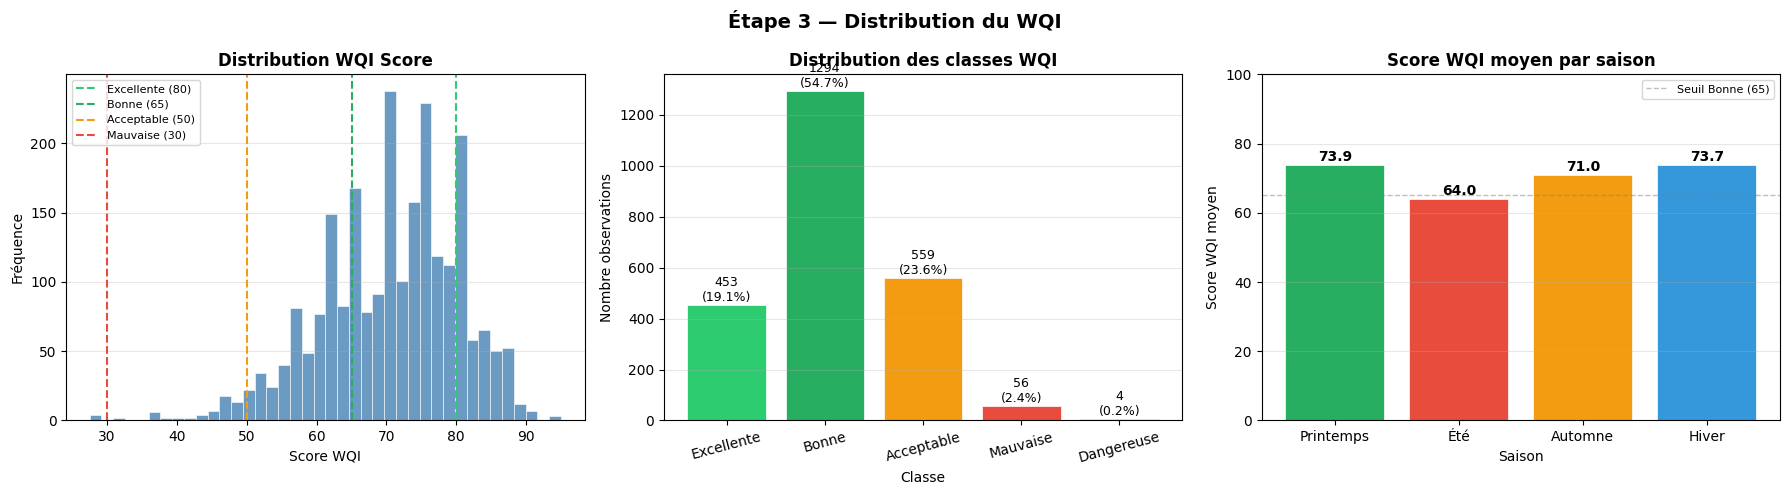

Visualisation WQI sauvegardée

 DÉSÉQUILIBRE DÉTECTÉ :
   Classe Mauvaise   :  56 observations (2.4%)  ← sous-représentée
   Classe Dangereuse :   4 observations (0.2%)  ← critique

   → SMOTE nécessaire sur classes 3 et 4


In [17]:
# Étape 3 — Cellule 4 : Visualisation distribution WQI

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Étape 3 — Distribution du WQI', fontsize=14, fontweight='bold')

# ── Graphique 1 : Histogramme WQI Score ─────────────────────────────────────
ax1 = axes[0]
colors_map = []
for score in df_clean['WQI_Score']:
    if   score >= 80 : colors_map.append('#2ecc71')
    elif score >= 65 : colors_map.append('#27ae60')
    elif score >= 50 : colors_map.append('#f39c12')
    elif score >= 30 : colors_map.append('#e74c3c')
    else             : colors_map.append('#8e44ad')

ax1.hist(df_clean['WQI_Score'], bins=40, color='steelblue',
         edgecolor='white', linewidth=0.5, alpha=0.8)
ax1.axvline(80, color='#2ecc71', linestyle='--', linewidth=1.5, label='Excellente (80)')
ax1.axvline(65, color='#27ae60', linestyle='--', linewidth=1.5, label='Bonne (65)')
ax1.axvline(50, color='#f39c12', linestyle='--', linewidth=1.5, label='Acceptable (50)')
ax1.axvline(30, color='#e74c3c', linestyle='--', linewidth=1.5, label='Mauvaise (30)')
ax1.set_title('Distribution WQI Score', fontweight='bold')
ax1.set_xlabel('Score WQI')
ax1.set_ylabel('Fréquence')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

# ── Graphique 2 : Distribution des classes ───────────────────────────────────
ax2 = axes[1]
labels_ordre = ['Excellente', 'Bonne', 'Acceptable', 'Mauvaise', 'Dangereuse']
colors_bar   = ['#2ecc71',    '#27ae60', '#f39c12',  '#e74c3c',  '#8e44ad']
counts = [df_clean[df_clean['WQI_Label'] == l].shape[0] for l in labels_ordre]
bars = ax2.bar(labels_ordre, counts, color=colors_bar,
               edgecolor='white', linewidth=0.5)
for bar, count in zip(bars, counts):
    pct = count / len(df_clean) * 100
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax2.set_title('Distribution des classes WQI', fontweight='bold')
ax2.set_xlabel('Classe')
ax2.set_ylabel('Nombre observations')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)

# ── Graphique 3 : WQI moyen par saison ───────────────────────────────────────
ax3 = axes[2]
saisons      = ['Printemps', 'Été', 'Automne', 'Hiver']
colors_saison= ['#27ae60',   '#e74c3c', '#f39c12', '#3498db']
wqi_saison   = [df_clean[df_clean['Season']==s]['WQI_Score'].mean() for s in saisons]
bars3 = ax3.bar(saisons, wqi_saison, color=colors_saison,
                edgecolor='white', linewidth=0.5)
for bar, val in zip(bars3, wqi_saison):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Score WQI moyen par saison', fontweight='bold')
ax3.set_xlabel('Saison')
ax3.set_ylabel('Score WQI moyen')
ax3.set_ylim(0, 100)
ax3.axhline(65, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Seuil Bonne (65)')
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etape3_distribution_wqi.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualisation WQI sauvegardée")
print("\n DÉSÉQUILIBRE DÉTECTÉ :")
print("="*60)
print(f"   Classe Mauvaise   :  56 observations (2.4%)  ← sous-représentée")
print(f"   Classe Dangereuse :   4 observations (0.2%)  ← critique")
print(f"\n   → SMOTE nécessaire sur classes 3 et 4")

In [18]:
# Étape 3 — Cellule 5 : Traitement du déséquilibre avec SMOTE

from imblearn.over_sampling import SMOTE
from collections import Counter

# Colonnes features pour SMOTE
features_cols = [
    'Salinity (ppt)',
    'DissolvedOxygen (mg/L)',
    'pH',
    'SecchiDepth (m)',
    'WaterDepth (m)',
    'WaterTemp (C)',
    'AirTemp (C)'
]

X = df_clean[features_cols]
y = df_clean['WQI_Class']

print(" DISTRIBUTION AVANT SMOTE :")
print("="*60)
counter_before = Counter(y)
labels = {0:'Excellente', 1:'Bonne', 2:'Acceptable', 3:'Mauvaise', 4:'Dangereuse'}
for classe in sorted(counter_before):
    count = counter_before[classe]
    pct   = count / len(y) * 100
    bar   = '█' * int(pct / 2)
    print(f"   Classe {classe} ({labels[classe]:<12}) : {count:>5} ({pct:5.1f}%) {bar}")

# Stratégie SMOTE — on cible un minimum de 200 par classe
strategie = {
    0 : 453,    # Excellente  — on garde
    1 : 1294,   # Bonne       — on garde
    2 : 559,    # Acceptable  — on garde
    3 : 300,    # Mauvaise    — on augmente  56  → 300
    4 : 200,    # Dangereuse  — on augmente   4  → 200
}

print(f"\n🔧 APPLICATION SMOTE :")
print("="*60)
print(f"   Stratégie ciblée :")
for classe, target in strategie.items():
    avant = counter_before[classe]
    diff  = target - avant
    action = f"+{diff} synthétiques" if diff > 0 else "inchangé"
    print(f"   Classe {classe} ({labels[classe]:<12}) : {avant:>5} → {target:>5}  ({action})")

smote = SMOTE(sampling_strategy=strategie, random_state=42, k_neighbors=3)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"\n DISTRIBUTION APRÈS SMOTE :")
print("="*60)
counter_after = Counter(y_resampled)
total_after   = len(y_resampled)
for classe in sorted(counter_after):
    count = counter_after[classe]
    pct   = count / total_after * 100
    bar   = '█' * int(pct / 2)
    print(f"   Classe {classe} ({labels[classe]:<12}) : {count:>5} ({pct:5.1f}%) {bar}")

print(f"\n RÉSUMÉ :")
print("="*60)
print(f"   Observations avant SMOTE : {len(X):>5}")
print(f"   Observations après SMOTE : {len(X_resampled):>5}")
print(f"   Observations synthétiques: {len(X_resampled)-len(X):>5}")

# Sauvegarde dataset final
df_smote = pd.DataFrame(X_resampled, columns=features_cols)
df_smote['WQI_Class'] = y_resampled
df_smote['WQI_Label'] = df_smote['WQI_Class'].map(labels)

df_smote.to_csv('water_quality_wqi_smote.csv', index=False)
print(f"\n Dataset final sauvegardé → water_quality_wqi_smote.csv")


 DISTRIBUTION AVANT SMOTE :
   Classe 0 (Excellente  ) :   453 ( 19.1%) █████████
   Classe 1 (Bonne       ) :  1294 ( 54.7%) ███████████████████████████
   Classe 2 (Acceptable  ) :   559 ( 23.6%) ███████████
   Classe 3 (Mauvaise    ) :    56 (  2.4%) █
   Classe 4 (Dangereuse  ) :     4 (  0.2%) 

🔧 APPLICATION SMOTE :
   Stratégie ciblée :
   Classe 0 (Excellente  ) :   453 →   453  (inchangé)
   Classe 1 (Bonne       ) :  1294 →  1294  (inchangé)
   Classe 2 (Acceptable  ) :   559 →   559  (inchangé)
   Classe 3 (Mauvaise    ) :    56 →   300  (+244 synthétiques)
   Classe 4 (Dangereuse  ) :     4 →   200  (+196 synthétiques)

 DISTRIBUTION APRÈS SMOTE :
   Classe 0 (Excellente  ) :   453 ( 16.1%) ████████
   Classe 1 (Bonne       ) :  1294 ( 46.1%) ███████████████████████
   Classe 2 (Acceptable  ) :   559 ( 19.9%) █████████
   Classe 3 (Mauvaise    ) :   300 ( 10.7%) █████
   Classe 4 (Dangereuse  ) :   200 (  7.1%) ███

 RÉSUMÉ :
   Observations avant SMOTE :  2366
   Observati

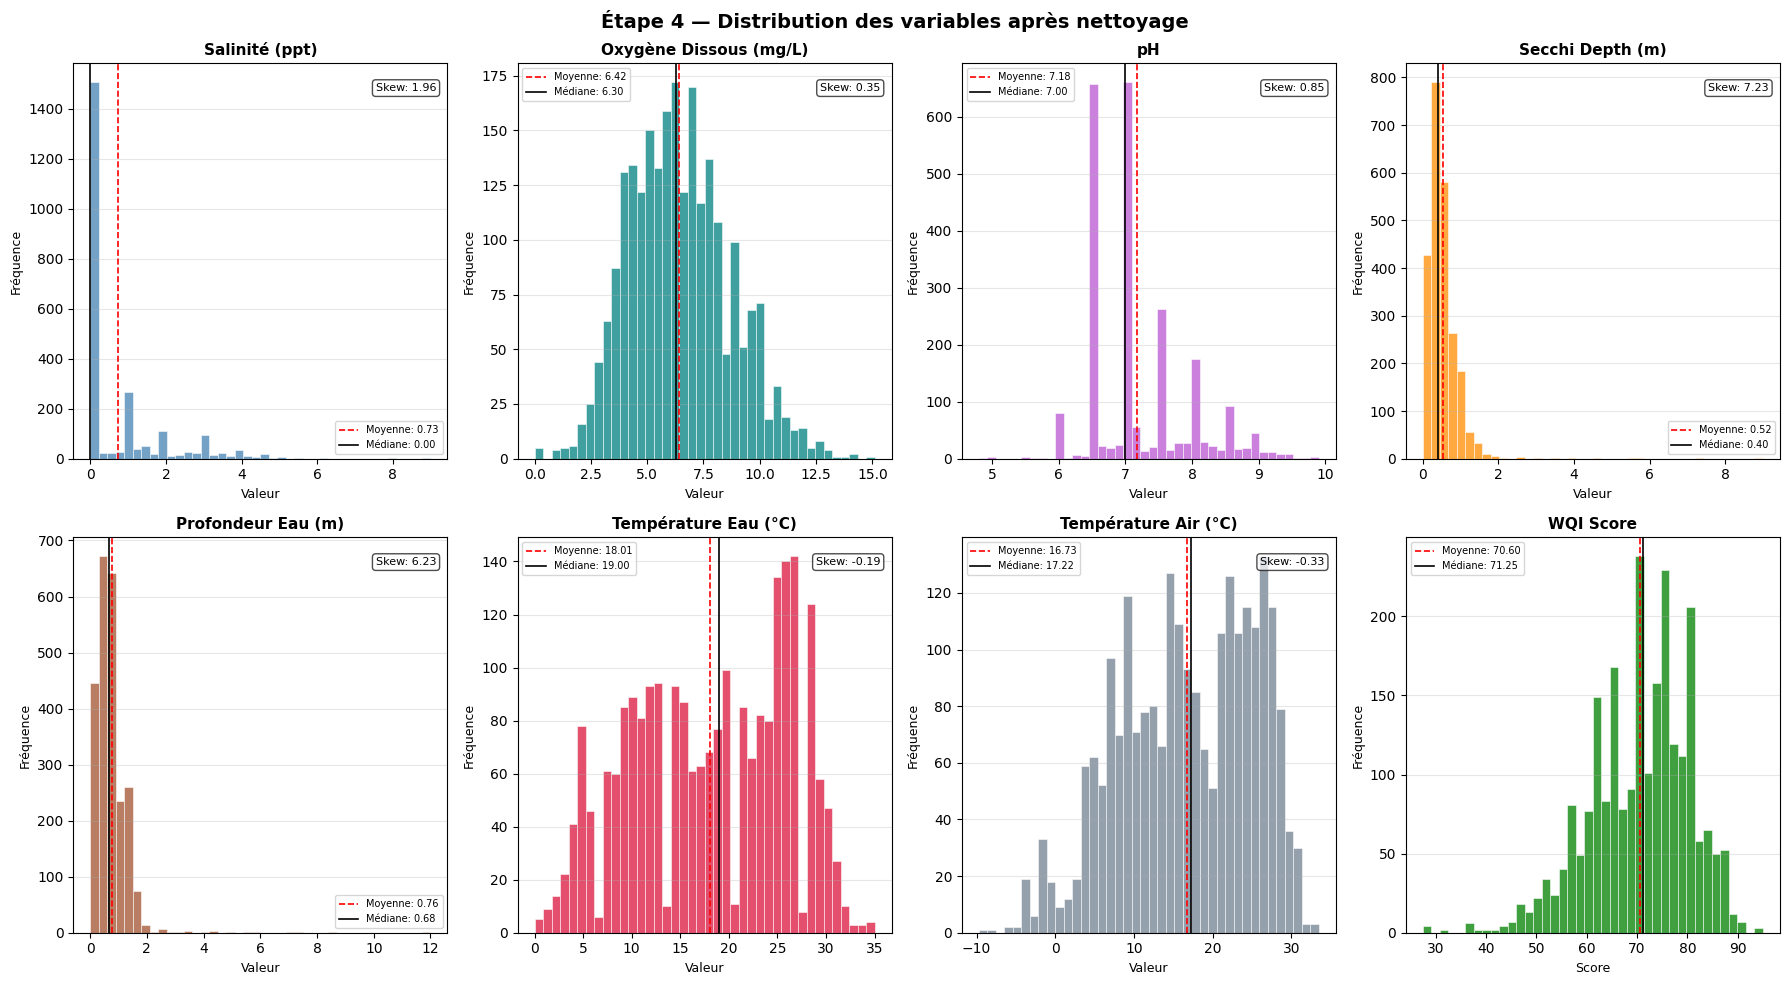

 Distribution des variables visualisée

 SKEWNESS PAR VARIABLE :
   Salinité (ppt)               :  1.957   Très asymétrique
   Oxygène Dissous (mg/L)       :  0.347   Symétrique
   pH                           :  0.852    Légèrement asymétrique
   Secchi Depth (m)             :  7.226   Très asymétrique
   Profondeur Eau (m)           :  6.228   Très asymétrique
   Température Eau (°C)         : -0.186   Symétrique
   Température Air (°C)         : -0.333   Symétrique


In [19]:
# Étape 4 — Cellule 1 : Distribution des variables après nettoyage

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Étape 4 — Distribution des variables après nettoyage', 
             fontsize=14, fontweight='bold')

variables = [
    ('Salinity (ppt)',         'Salinité (ppt)',          'steelblue'),
    ('DissolvedOxygen (mg/L)', 'Oxygène Dissous (mg/L)',  'teal'),
    ('pH',                     'pH',                      'mediumorchid'),
    ('SecchiDepth (m)',        'Secchi Depth (m)',         'darkorange'),
    ('WaterDepth (m)',         'Profondeur Eau (m)',       'sienna'),
    ('WaterTemp (C)',          'Température Eau (°C)',     'crimson'),
    ('AirTemp (C)',            'Température Air (°C)',     'slategray'),
]

for idx, (col, label, color) in enumerate(variables):
    row, col_idx = divmod(idx, 4)
    ax = axes[row][col_idx]
    data = df_clean[col]

    ax.hist(data, bins=40, color=color, alpha=0.75,
            edgecolor='white', linewidth=0.5)

    # Lignes statistiques
    mean_val   = data.mean()
    median_val = data.median()
    ax.axvline(mean_val,   color='red',   linestyle='--',
               linewidth=1.2, label=f'Moyenne: {mean_val:.2f}')
    ax.axvline(median_val, color='black', linestyle='-',
               linewidth=1.2, label=f'Médiane: {median_val:.2f}')

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Valeur', fontsize=9)
    ax.set_ylabel('Fréquence', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(axis='y', alpha=0.3)

    # Skewness
    skew = data.skew()
    ax.text(0.97, 0.95, f'Skew: {skew:.2f}',
            transform=ax.transAxes, fontsize=8,
            ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Dernière case — WQI Score
ax_wqi = axes[1][3]
ax_wqi.hist(df_clean['WQI_Score'], bins=40, color='green',
            alpha=0.75, edgecolor='white', linewidth=0.5)
ax_wqi.axvline(df_clean['WQI_Score'].mean(), color='red',
               linestyle='--', linewidth=1.2,
               label=f"Moyenne: {df_clean['WQI_Score'].mean():.2f}")
ax_wqi.axvline(df_clean['WQI_Score'].median(), color='black',
               linestyle='-', linewidth=1.2,
               label=f"Médiane: {df_clean['WQI_Score'].median():.2f}")
ax_wqi.set_title('WQI Score', fontsize=11, fontweight='bold')
ax_wqi.set_xlabel('Score', fontsize=9)
ax_wqi.set_ylabel('Fréquence', fontsize=9)
ax_wqi.legend(fontsize=7)
ax_wqi.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etape4_distribution_variables.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Distribution des variables visualisée")
print("\n SKEWNESS PAR VARIABLE :")
print("="*55)
for col, label, _ in variables:
    skew = df_clean[col].skew()
    if   abs(skew) < 0.5  : interpretation = " Symétrique"
    elif abs(skew) < 1.0  : interpretation = "  Légèrement asymétrique"
    else                  : interpretation = " Très asymétrique"
    print(f"   {label:<28} : {skew:>6.3f}  {interpretation}")

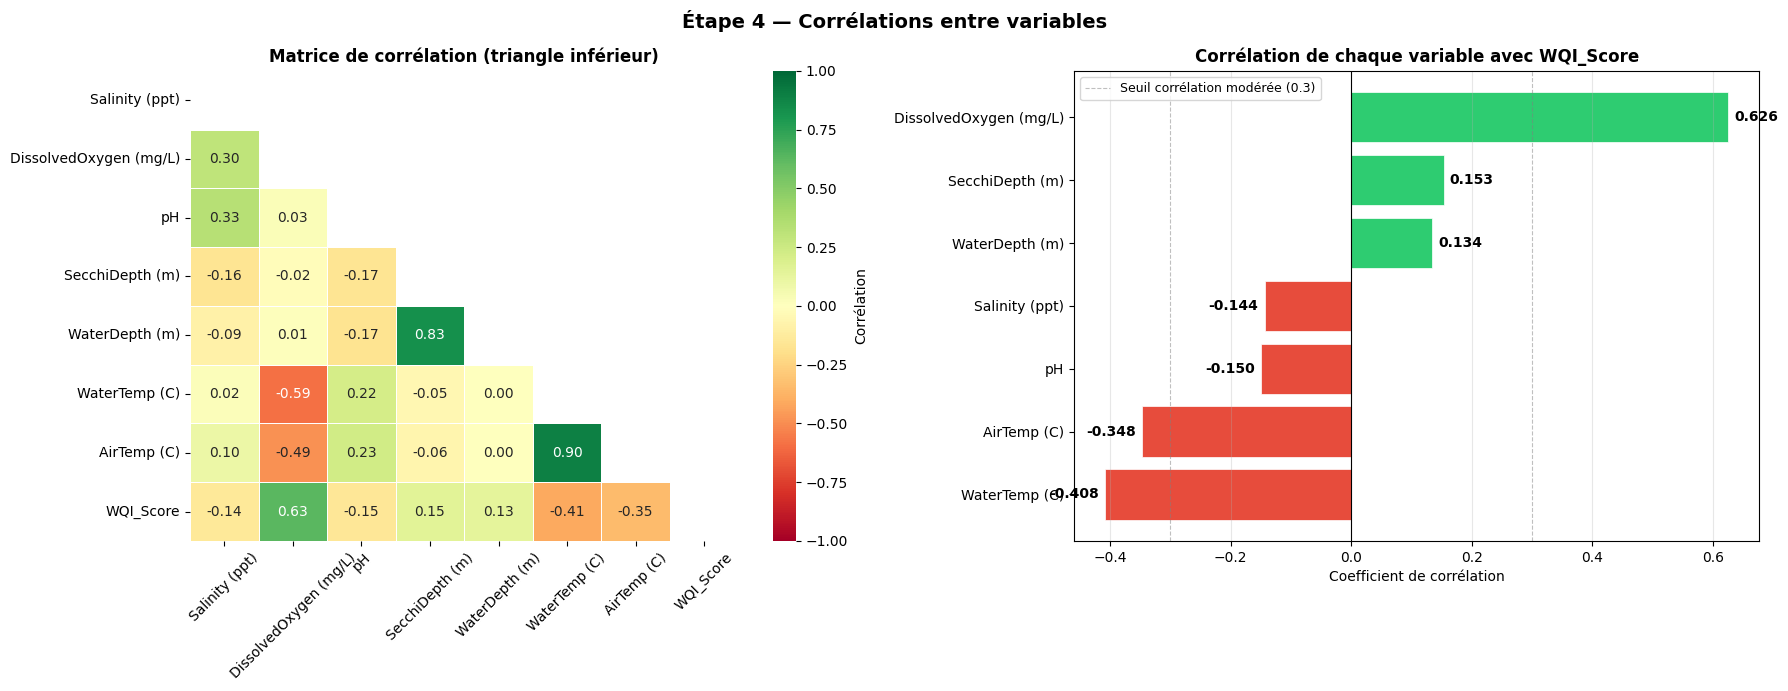

 Matrice de corrélation visualisée

 CORRÉLATIONS AVEC WQI_Score (triées) :
   WaterTemp (C)                :  -0.408  🟠 Modérée négative
   AirTemp (C)                  :  -0.348  🟠 Modérée négative
   pH                           :  -0.150  🟢 Faible négative
   Salinity (ppt)               :  -0.144  🟢 Faible négative
   WaterDepth (m)               :   0.134  🟢 Faible positive
   SecchiDepth (m)              :   0.153  🟢 Faible positive
   DissolvedOxygen (mg/L)       :   0.626  🔴 Forte positive


In [20]:
# Étape 4 — Cellule 2 : Matrice de corrélation

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Étape 4 — Corrélations entre variables', 
             fontsize=14, fontweight='bold')

num_cols = [
    'Salinity (ppt)',
    'DissolvedOxygen (mg/L)',
    'pH',
    'SecchiDepth (m)',
    'WaterDepth (m)',
    'WaterTemp (C)',
    'AirTemp (C)',
    'WQI_Score'
]

corr_matrix = df_clean[num_cols].corr()

# ── Graphique 1 : Heatmap complète ──────────────────────────────────────────
ax1 = axes[0]
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax1,
            cbar_kws={'label': 'Corrélation'})
ax1.set_title('Matrice de corrélation (triangle inférieur)', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.tick_params(axis='y', rotation=0)

# ── Graphique 2 : Corrélations avec WQI_Score ───────────────────────────────
ax2 = axes[1]
corr_wqi = corr_matrix['WQI_Score'].drop('WQI_Score').sort_values()
colors   = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_wqi.values]
bars     = ax2.barh(corr_wqi.index, corr_wqi.values,
                    color=colors, edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, corr_wqi.values):
    ax2.text(val + (0.01 if val >= 0 else -0.01),
             bar.get_y() + bar.get_height()/2,
             f'{val:.3f}',
             ha='left' if val >= 0 else 'right',
             va='center', fontsize=10, fontweight='bold')

ax2.axvline(0,    color='black', linewidth=0.8)
ax2.axvline(0.3,  color='gray',  linewidth=0.8,
            linestyle='--', alpha=0.5, label='Seuil corrélation modérée (0.3)')
ax2.axvline(-0.3, color='gray',  linewidth=0.8,
            linestyle='--', alpha=0.5)
ax2.set_title('Corrélation de chaque variable avec WQI_Score',
              fontweight='bold')
ax2.set_xlabel('Coefficient de corrélation')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('etape4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(" Matrice de corrélation visualisée")
print("\n CORRÉLATIONS AVEC WQI_Score (triées) :")
print("="*60)
for var, val in corr_wqi.items():
    if        abs(val) >= 0.5  : force = "🔴 Forte"
    elif      abs(val) >= 0.3  : force = "🟠 Modérée"
    else                       : force = "🟢 Faible"
    direction = "positive" if val > 0 else "négative"
    print(f"   {var:<28} : {val:>7.3f}  {force} {direction}")

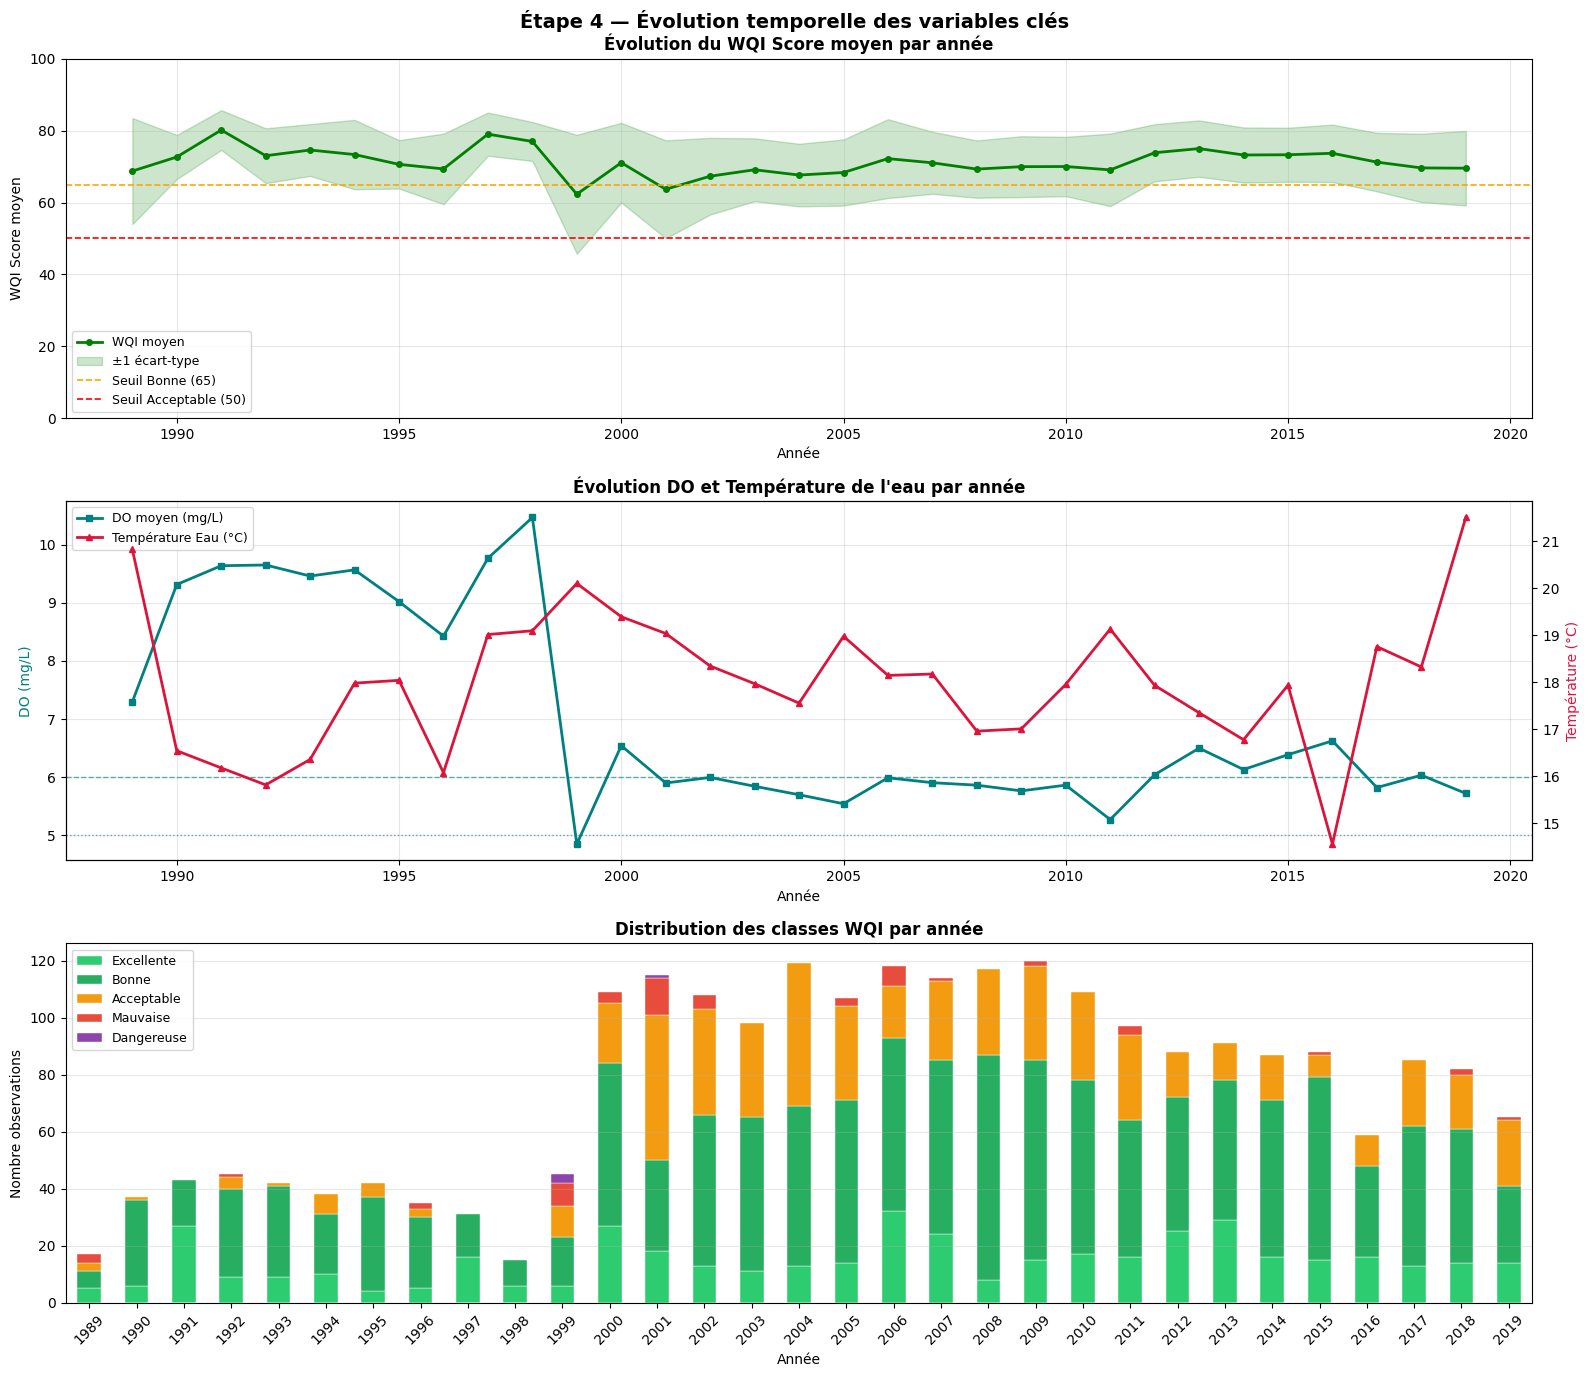

Analyse temporelle visualisée

ANNÉES CRITIQUES (WQI moyen < 65) :
     Année 1999 : WQI moyen = 62.31
     Année 2001 : WQI moyen = 63.68

 TENDANCE GÉNÉRALE :
   Pente      : -0.0514 points/an
   Tendance   : dégradation
   R²         : 0.0150
   p-value    : 0.5111 %  non significatif


In [21]:
# Étape 4 — Cellule 3 : Analyse temporelle

fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.suptitle('Étape 4 — Évolution temporelle des variables clés',
             fontsize=14, fontweight='bold')

# ── Graphique 1 : WQI Score par année ───────────────────────────────────────
ax1 = axes[0]
wqi_annuel = df_clean.groupby('Year')['WQI_Score'].agg(['mean','std']).reset_index()

ax1.plot(wqi_annuel['Year'], wqi_annuel['mean'],
         color='green', linewidth=2, marker='o', markersize=4, label='WQI moyen')
ax1.fill_between(wqi_annuel['Year'],
                 wqi_annuel['mean'] - wqi_annuel['std'],
                 wqi_annuel['mean'] + wqi_annuel['std'],
                 alpha=0.2, color='green', label='±1 écart-type')
ax1.axhline(65, color='orange', linestyle='--', linewidth=1.2, label='Seuil Bonne (65)')
ax1.axhline(50, color='red',    linestyle='--', linewidth=1.2, label='Seuil Acceptable (50)')
ax1.set_title('Évolution du WQI Score moyen par année', fontweight='bold')
ax1.set_xlabel('Année')
ax1.set_ylabel('WQI Score moyen')
ax1.set_ylim(0, 100)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Graphique 2 : DO et WaterTemp par année ──────────────────────────────────
ax2 = axes[1]
do_annuel   = df_clean.groupby('Year')['DissolvedOxygen (mg/L)'].mean()
temp_annuel = df_clean.groupby('Year')['WaterTemp (C)'].mean()

ax2_twin = ax2.twinx()
l1, = ax2.plot(do_annuel.index, do_annuel.values,
               color='teal', linewidth=2, marker='s',
               markersize=4, label='DO moyen (mg/L)')
l2, = ax2_twin.plot(temp_annuel.index, temp_annuel.values,
                    color='crimson', linewidth=2, marker='^',
                    markersize=4, label='Température Eau (°C)')
ax2.axhline(6, color='teal',   linestyle='--', linewidth=1, alpha=0.6, label='Seuil DO Bonne (6)')
ax2.axhline(5, color='teal',   linestyle=':',  linewidth=1, alpha=0.6, label='Seuil DO Acceptable (5)')
ax2.set_title('Évolution DO et Température de l\'eau par année', fontweight='bold')
ax2.set_xlabel('Année')
ax2.set_ylabel('DO (mg/L)', color='teal')
ax2_twin.set_ylabel('Température (°C)', color='crimson')
lines = [l1, l2]
ax2.legend(lines, [l.get_label() for l in lines], fontsize=9, loc='upper left')
ax2.grid(alpha=0.3)

# ── Graphique 3 : Distribution classes WQI par année ────────────────────────
ax3 = axes[2]
classes_annuel = df_clean.groupby(['Year', 'WQI_Label']).size().unstack(fill_value=0)
labels_ordre   = ['Excellente', 'Bonne', 'Acceptable', 'Mauvaise', 'Dangereuse']
colors_stack   = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad']

# Garder seulement les colonnes présentes
labels_present = [l for l in labels_ordre if l in classes_annuel.columns]
colors_present = [colors_stack[labels_ordre.index(l)] for l in labels_present]

classes_annuel[labels_present].plot(
    kind='bar', stacked=True, ax=ax3,
    color=colors_present, edgecolor='white', linewidth=0.3
)
ax3.set_title('Distribution des classes WQI par année', fontweight='bold')
ax3.set_xlabel('Année')
ax3.set_ylabel('Nombre observations')
ax3.legend(fontsize=9, loc='upper left')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etape4_evolution_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

print("Analyse temporelle visualisée")
print("\nANNÉES CRITIQUES (WQI moyen < 65) :")
print("="*55)
annees_critiques = wqi_annuel[wqi_annuel['mean'] < 65]
if len(annees_critiques) > 0:
    for _, row in annees_critiques.iterrows():
        print(f"     Année {int(row['Year'])} : WQI moyen = {row['mean']:.2f}")
else:
    print("    Aucune année avec WQI moyen < 65")

print("\n TENDANCE GÉNÉRALE :")
print("="*55)
from scipy import stats
slope, intercept, r, p, se = stats.linregress(
    wqi_annuel['Year'], wqi_annuel['mean']
)
tendance = "amélioration" if slope > 0 else "dégradation"
print(f"   Pente      : {slope:.4f} points/an")
print(f"   Tendance   : {tendance}")
print(f"   R²         : {r**2:.4f}")
print(f"   p-value    : {p:.4f} {' significatif' if p < 0.05 else '%  non significatif'}")

 VÉRIFICATION — Colonne zone géographique :
   Colonnes disponibles : ['Date', 'Salinity (ppt)', 'DissolvedOxygen (mg/L)', 'pH', 'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)', 'Year', 'Month', 'Season', 'SI_pH', 'SI_DO', 'SI_Sal', 'SI_Temp', 'SI_Secchi', 'WQI_Score', 'WQI_Class', 'WQI_Label']

   ⚠️  Aucune colonne zone trouvée — création par clustering géographique
   → On utilise WaterDepth comme proxy de zone :
      Zone A — Eaux peu profondes  (WaterDepth ≤ 1.0m)  → zone côtière
      Zone B — Eaux intermédiaires (WaterDepth ≤ 3.0m)  → lagon
      Zone C — Eaux profondes      (WaterDepth  > 3.0m) → large

    Colonne 'Zone' créée

📊 DISTRIBUTION PAR ZONE :
   Zone_Cotiere         :  1870 observations ( 79.0%) ██████████████████████████
   Zone_Lagon           :   480 observations ( 20.3%) ██████
   Zone_Large           :    16 observations (  0.7%) 

📊 WQI MOYEN PAR ZONE :
               mean    std    min    max
Zone                                    
Zone_

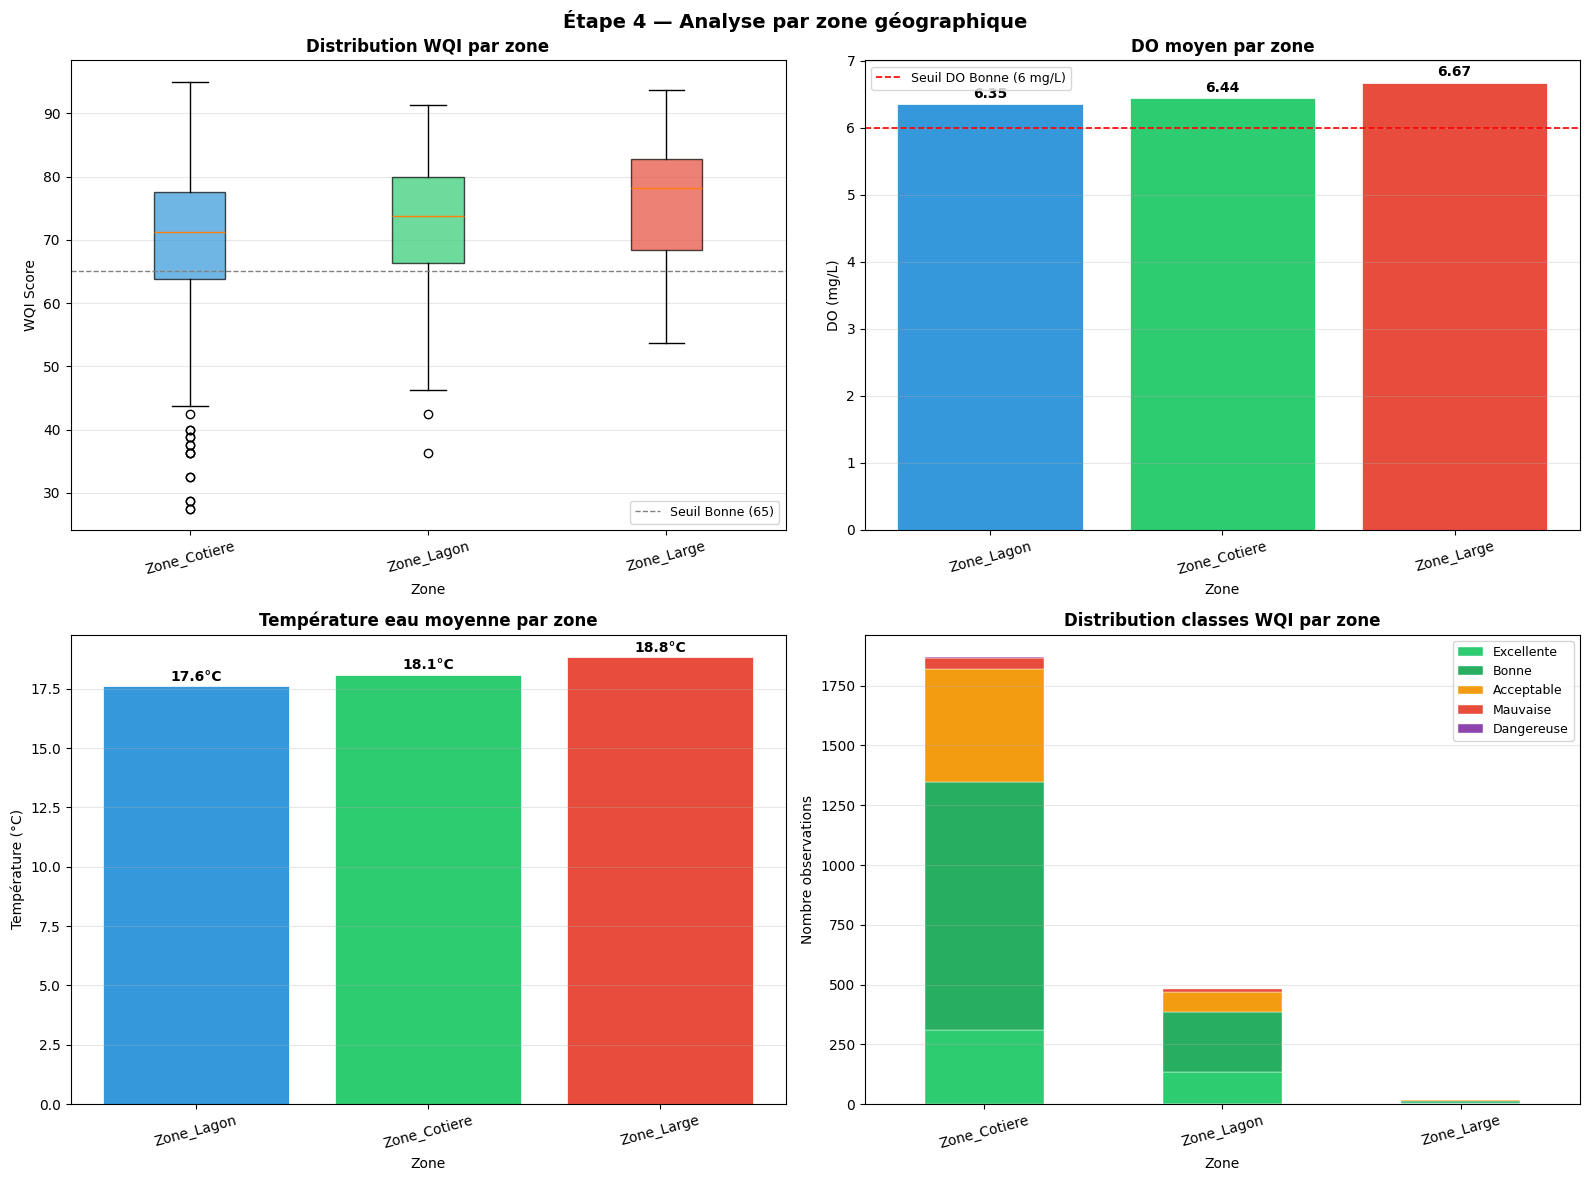


 Analyse géographique visualisée

 BILAN PAR ZONE :

   📍 Zone_Cotiere
      WQI moyen    : 70.05
      DO moyen     : 6.44 mg/L
      Temp. moy.   : 18.1 °C
      Classe dom.  : Bonne

   📍 Zone_Lagon
      WQI moyen    : 72.60
      DO moyen     : 6.35 mg/L
      Temp. moy.   : 17.6 °C
      Classe dom.  : Bonne

   📍 Zone_Large
      WQI moyen    : 75.23
      DO moyen     : 6.67 mg/L
      Temp. moy.   : 18.8 °C
      Classe dom.  : Bonne


In [22]:
# Étape 4 — Cellule 4 : Analyse par zone géographique

print(" VÉRIFICATION — Colonne zone géographique :")
print("="*60)
print(f"   Colonnes disponibles : {list(df_clean.columns)}")

# Vérification si une colonne de zone existe
zone_col = None
for col in df_clean.columns:
    if any(kw in col.lower() for kw in ['zone', 'site', 'location', 'station', 'pool', 'bay']):
        zone_col = col
        print(f"\n    Colonne zone trouvée : '{zone_col}'")
        break

if zone_col is None:
    print("\n   ⚠️  Aucune colonne zone trouvée — création par clustering géographique")
    print("   → On utilise WaterDepth comme proxy de zone :")
    print("      Zone A — Eaux peu profondes  (WaterDepth ≤ 1.0m)  → zone côtière")
    print("      Zone B — Eaux intermédiaires (WaterDepth ≤ 3.0m)  → lagon")
    print("      Zone C — Eaux profondes      (WaterDepth  > 3.0m) → large")

    def assign_zone(depth):
        if   depth <= 1.0 : return 'Zone_Cotiere'
        elif depth <= 3.0 : return 'Zone_Lagon'
        else              : return 'Zone_Large'

    df_clean['Zone'] = df_clean['WaterDepth (m)'].apply(assign_zone)
    zone_col = 'Zone'
    print(f"\n    Colonne '{zone_col}' créée")

# Distribution des zones
print(f"\n📊 DISTRIBUTION PAR ZONE :")
print("="*60)
zone_counts = df_clean[zone_col].value_counts()
for zone, count in zone_counts.items():
    pct = count / len(df_clean) * 100
    bar = '█' * int(pct / 3)
    print(f"   {zone:<20} : {count:>5} observations ({pct:5.1f}%) {bar}")

# Statistiques WQI par zone
print(f"\n📊 WQI MOYEN PAR ZONE :")
print("="*60)
wqi_zone = df_clean.groupby(zone_col)['WQI_Score'].agg(['mean','std','min','max']).round(2)
print(wqi_zone)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Étape 4 — Analyse par zone géographique',
             fontsize=14, fontweight='bold')

colors_zones = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
zones        = df_clean[zone_col].unique()

# ── Graphique 1 : Boxplot WQI par zone ──────────────────────────────────────
ax1 = axes[0][0]
data_boxplot = [df_clean[df_clean[zone_col] == z]['WQI_Score'].values for z in zones]
bp = ax1.boxplot(data_boxplot, patch_artist=True, labels=zones)
for patch, color in zip(bp['boxes'], colors_zones[:len(zones)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.axhline(65, color='gray', linestyle='--', linewidth=1, label='Seuil Bonne (65)')
ax1.set_title('Distribution WQI par zone', fontweight='bold')
ax1.set_xlabel('Zone')
ax1.set_ylabel('WQI Score')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=15)

# ── Graphique 2 : DO moyen par zone ──────────────────────────────────────────
ax2 = axes[0][1]
do_zone  = df_clean.groupby(zone_col)['DissolvedOxygen (mg/L)'].mean().sort_values()
bars2 = ax2.bar(do_zone.index, do_zone.values,
                color=colors_zones[:len(do_zone)], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, do_zone.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(6.0, color='red', linestyle='--', linewidth=1.2, label='Seuil DO Bonne (6 mg/L)')
ax2.set_title('DO moyen par zone', fontweight='bold')
ax2.set_xlabel('Zone')
ax2.set_ylabel('DO (mg/L)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=15)

# ── Graphique 3 : Température eau par zone ───────────────────────────────────
ax3 = axes[1][0]
temp_zone = df_clean.groupby(zone_col)['WaterTemp (C)'].mean().sort_values()
bars3 = ax3.bar(temp_zone.index, temp_zone.values,
                color=colors_zones[:len(temp_zone)], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars3, temp_zone.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}°C', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_title('Température eau moyenne par zone', fontweight='bold')
ax3.set_xlabel('Zone')
ax3.set_ylabel('Température (°C)')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=15)

# ── Graphique 4 : Distribution classes WQI par zone (stacked) ────────────────
ax4 = axes[1][1]
labels_ordre = ['Excellente', 'Bonne', 'Acceptable', 'Mauvaise', 'Dangereuse']
colors_stack = ['#2ecc71',    '#27ae60', '#f39c12',  '#e74c3c',  '#8e44ad']

classes_zone = df_clean.groupby([zone_col, 'WQI_Label']).size().unstack(fill_value=0)
labels_present = [l for l in labels_ordre if l in classes_zone.columns]
colors_present = [colors_stack[labels_ordre.index(l)] for l in labels_present]

classes_zone[labels_present].plot(
    kind='bar', stacked=True, ax=ax4,
    color=colors_present, edgecolor='white', linewidth=0.3
)
ax4.set_title('Distribution classes WQI par zone', fontweight='bold')
ax4.set_xlabel('Zone')
ax4.set_ylabel('Nombre observations')
ax4.legend(fontsize=9, loc='upper right')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etape4_analyse_zones.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Analyse géographique visualisée")
print("\n BILAN PAR ZONE :")
print("="*60)
for zone in df_clean[zone_col].unique():
    sub    = df_clean[df_clean[zone_col] == zone]
    wqi_m  = sub['WQI_Score'].mean()
    do_m   = sub['DissolvedOxygen (mg/L)'].mean()
    tmp_m  = sub['WaterTemp (C)'].mean()
    classe = sub['WQI_Label'].value_counts().idxmax()
    print(f"\n   📍 {zone}")
    print(f"      WQI moyen    : {wqi_m:.2f}")
    print(f"      DO moyen     : {do_m:.2f} mg/L")
    print(f"      Temp. moy.   : {tmp_m:.1f} °C")
    print(f"      Classe dom.  : {classe}")

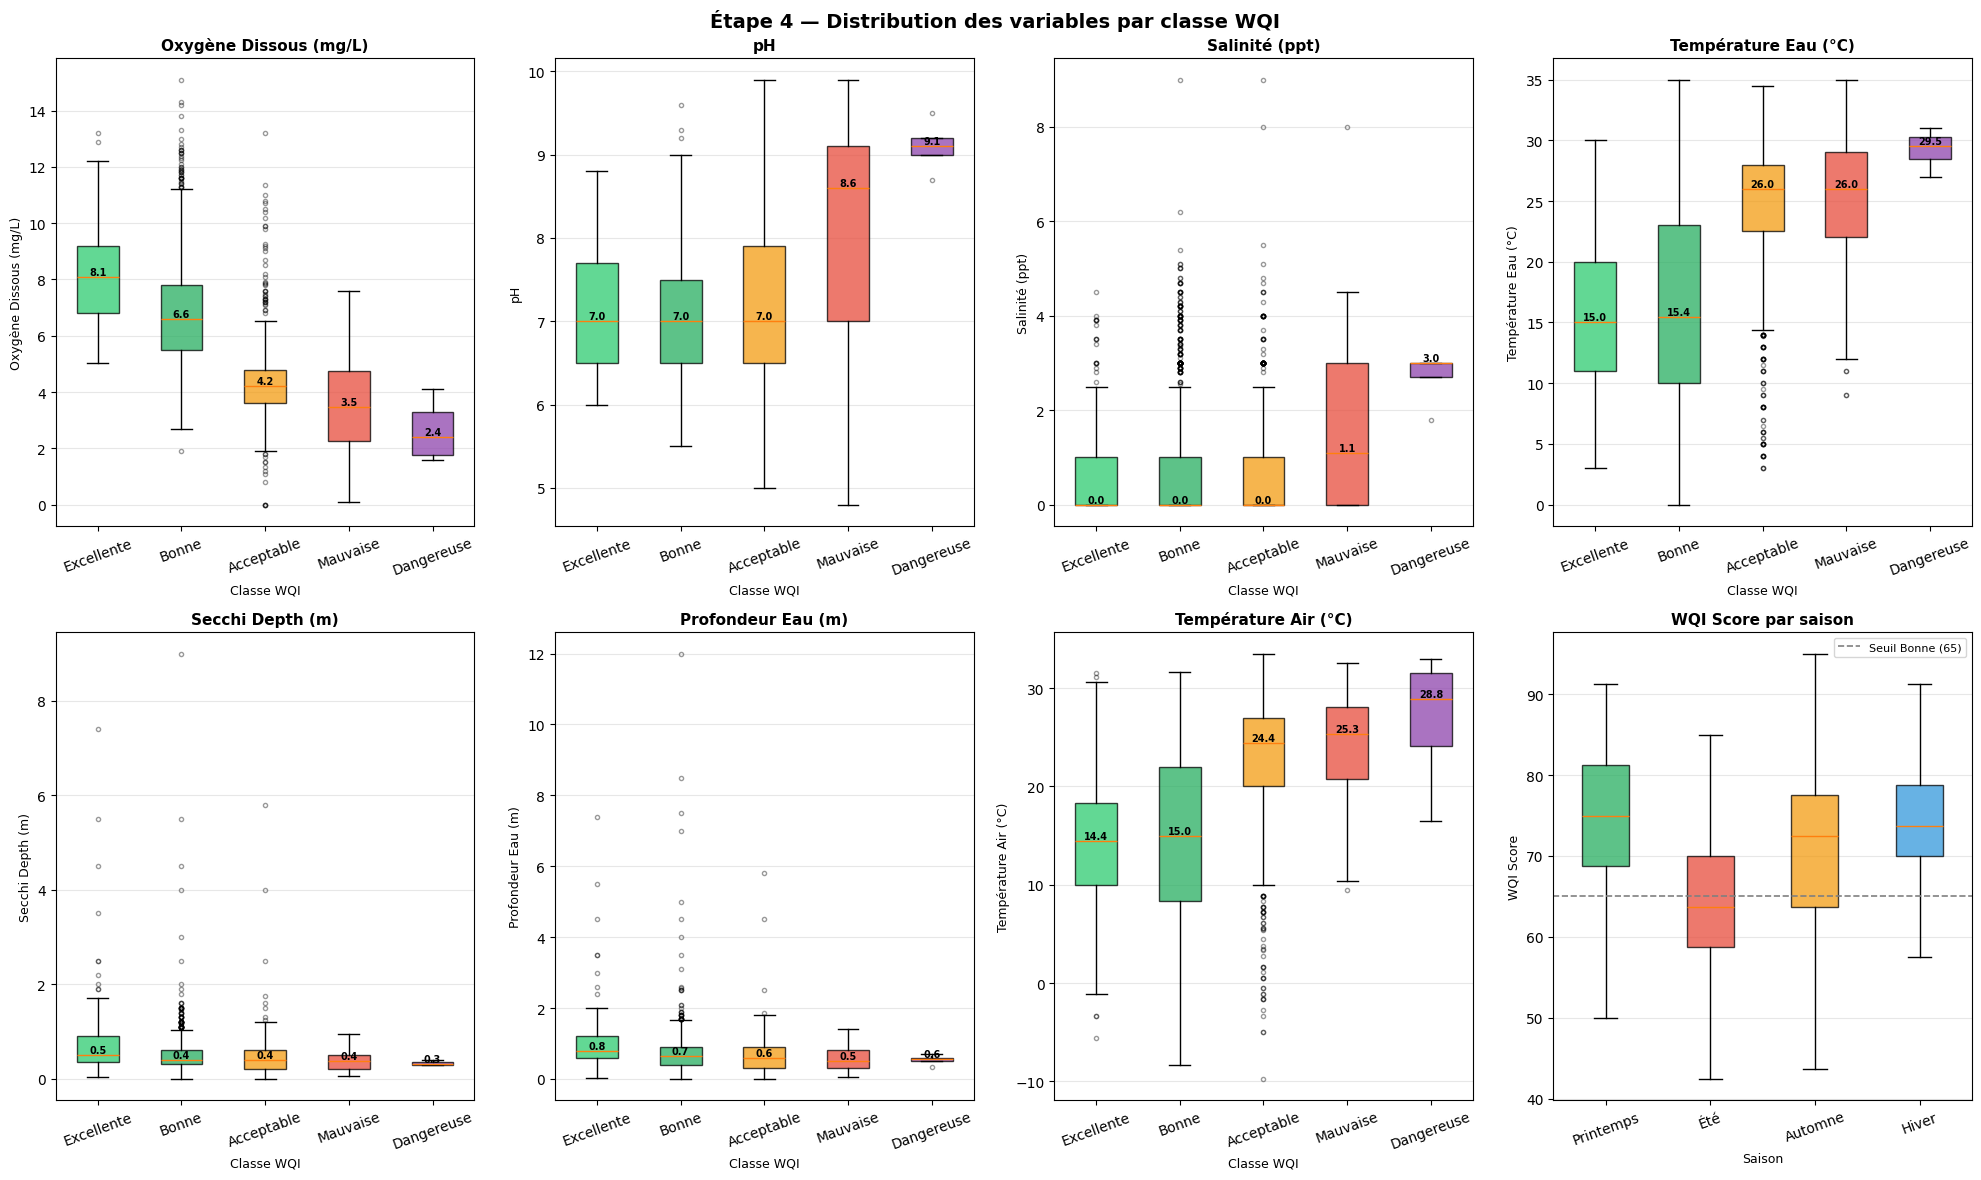

TEST ANOVA — Différences significatives entre classes WQI :
   Variable                         F-stat     p-value  Significatif ?
   -------------------------------------------------------
   Oxygène Dissous (mg/L)           352.52      0.0000   OUI
   pH                                34.39      0.0000   OUI
   Salinité (ppt)                    12.86      0.0000   OUI
   Température Eau (°C)             148.30      0.0000   OUI
   Secchi Depth (m)                  17.72      0.0000   OUI
   Profondeur Eau (m)                13.37      0.0000   OUI
   Température Air (°C)             102.67      0.0000   OUI

📊 CORRÉLATION RANG (Spearman) — Variables vs WQI_Class :
   Variable                            rho     p-value  Interprétation
   -------------------------------------------------------
   Oxygène Dissous (mg/L)           -0.643      0.0000  🔴 Forte inverse
   pH                                0.026      0.2009  🟢 Faible directe
   Salinité (ppt)                    0.052      0.

In [23]:
# Étape 4 — Cellule 5 : Relation entre variables et classes WQI

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle('Étape 4 — Distribution des variables par classe WQI',
             fontsize=14, fontweight='bold')

variables = [
    ('DissolvedOxygen (mg/L)', 'Oxygène Dissous (mg/L)', 'teal'),
    ('pH',                     'pH',                      'mediumorchid'),
    ('Salinity (ppt)',         'Salinité (ppt)',           'steelblue'),
    ('WaterTemp (C)',          'Température Eau (°C)',     'crimson'),
    ('SecchiDepth (m)',        'Secchi Depth (m)',          'darkorange'),
    ('WaterDepth (m)',         'Profondeur Eau (m)',        'sienna'),
    ('AirTemp (C)',            'Température Air (°C)',      'slategray'),
]

ordre_classes = ['Excellente', 'Bonne', 'Acceptable', 'Mauvaise', 'Dangereuse']
colors_classes = ['#2ecc71',   '#27ae60', '#f39c12',   '#e74c3c',  '#8e44ad']

# Garder seulement les classes présentes dans df_clean
classes_presentes = [c for c in ordre_classes if c in df_clean['WQI_Label'].unique()]

for idx, (col, label, color) in enumerate(variables):
    row, col_idx = divmod(idx, 4)
    ax = axes[row][col_idx]

    data_per_class = [
        df_clean[df_clean['WQI_Label'] == cls][col].values
        for cls in classes_presentes
    ]
    colors_present = [colors_classes[ordre_classes.index(c)] for c in classes_presentes]

    bp = ax.boxplot(data_per_class,
                    patch_artist=True,
                    labels=classes_presentes,
                    showfliers=True,
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))

    for patch, c in zip(bp['boxes'], colors_present):
        patch.set_facecolor(c)
        patch.set_alpha(0.75)

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Classe WQI', fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.3)

    # Annotation médiane sur chaque boîte
    for i, d in enumerate(data_per_class):
        if len(d) > 0:
            median = np.median(d)
            ax.text(i + 1, median, f'{median:.1f}',
                    ha='center', va='bottom', fontsize=7,
                    fontweight='bold', color='black')

# Dernière case — WQI_Score par saison (récapitulatif)
ax_last = axes[1][3]
saisons      = ['Printemps', 'Été', 'Automne', 'Hiver']
colors_saison= ['#27ae60',   '#e74c3c', '#f39c12', '#3498db']
data_saison  = [df_clean[df_clean['Season'] == s]['WQI_Score'].values for s in saisons]

bp2 = ax_last.boxplot(data_saison, patch_artist=True, labels=saisons, showfliers=False)
for patch, c in zip(bp2['boxes'], colors_saison):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)

ax_last.axhline(65, color='gray', linestyle='--', linewidth=1.2, label='Seuil Bonne (65)')
ax_last.set_title('WQI Score par saison', fontsize=11, fontweight='bold')
ax_last.set_xlabel('Saison', fontsize=9)
ax_last.set_ylabel('WQI Score', fontsize=9)
ax_last.legend(fontsize=8)
ax_last.tick_params(axis='x', rotation=20)
ax_last.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('etape4_boxplots_classes.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Analyse statistique : ANOVA par classe ───────────────────────────────────
from scipy import stats

print("TEST ANOVA — Différences significatives entre classes WQI :")
print("="*65)
print(f"   {'Variable':<30} {'F-stat':>8}  {'p-value':>10}  Significatif ?")
print("   " + "-"*55)

for col, label, _ in variables:
    groups = [df_clean[df_clean['WQI_Label'] == cls][col].values
              for cls in classes_presentes if len(df_clean[df_clean['WQI_Label'] == cls]) > 1]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = " OUI" if p_val < 0.05 else " NON"
    print(f"   {label:<30} {f_stat:>8.2f}  {p_val:>10.4f}  {sig}")

print("\n📊 CORRÉLATION RANG (Spearman) — Variables vs WQI_Class :")
print("="*65)
print(f"   {'Variable':<30} {'rho':>8}  {'p-value':>10}  Interprétation")
print("   " + "-"*55)

for col, label, _ in variables:
    rho, p_val = stats.spearmanr(df_clean[col], df_clean['WQI_Class'])
    if   abs(rho) >= 0.5 : force = "🔴 Forte"
    elif abs(rho) >= 0.3 : force = "🟠 Modérée"
    else                 : force = "🟢 Faible"
    direction = "inverse" if rho < 0 else "directe"
    print(f"   {label:<30} {rho:>8.3f}  {p_val:>10.4f}  {force} {direction}")

In [25]:
# Étape 4 — Cellule 6 : Synthèse EDA et bilan avant Feature Engineering

print("=" * 65)
print("  BILAN COMPLET — ÉTAPE 4 : ANALYSE EXPLORATOIRE (EDA)")
print("=" * 65)

# ── 1. Résumé dataset ────────────────────────────────────────────────────────
print("\n 1. ÉTAT DU DATASET :")
print(f"   Observations    : {len(df_clean)}")
print(f"   Variables       : {len(df_clean.columns)}")
print(f"   Période         : {df_clean['Date'].min().date()} → {df_clean['Date'].max().date()}")
print(f"   Valeurs manq.   : {df_clean.isnull().sum().sum()} ✅")

# ── 2. Distribution des variables ────────────────────────────────────────────
print("\n 2. DISTRIBUTION DES VARIABLES (Skewness) :")
num_cols_eda = [
    'Salinity (ppt)', 'DissolvedOxygen (mg/L)', 'pH',
    'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)'
]
for col in num_cols_eda:
    skew = df_clean[col].skew()
    if   abs(skew) < 0.5 : tag = " Symétrique"
    elif abs(skew) < 1.0 : tag = "  Légèrement asymétrique"
    else                 : tag = "Très asymétrique → log-transform à considérer"
    print(f"   {col:<30} skew={skew:>6.3f}  {tag}")

# ── 3. Corrélations clés ─────────────────────────────────────────────────────
print("\n 3. CORRÉLATIONS CLÉS AVEC WQI_Score :")
corr_wqi = df_clean[num_cols_eda + ['WQI_Score']].corr()['WQI_Score'].drop('WQI_Score').sort_values()
for var, val in corr_wqi.items():
    if   abs(val) >= 0.5 : force = "🔴 Forte"
    elif abs(val) >= 0.3 : force = "🟠 Modérée"
    else                 : force = "🟢 Faible"
    print(f"   {var:<30} r={val:>7.3f}  {force}")

# ── 4. Analyse saisonnière ───────────────────────────────────────────────────
print("\n 4. EFFET SAISONNIER SUR LE WQI :")
saison_wqi = df_clean.groupby('Season')['WQI_Score'].agg(['mean', 'std']).round(2)
for saison, row in saison_wqi.iterrows():
    alerte = "  Dégradation estivale" if saison == 'Été' else "✅"
    print(f"   {saison:<12} : WQI={row['mean']:.2f} ± {row['std']:.2f}  {alerte}")

# ── 5. Analyse par zone ──────────────────────────────────────────────────────
print("\n5. DIFFÉRENCES PAR ZONE GÉOGRAPHIQUE :")
zone_wqi = df_clean.groupby('Zone')['WQI_Score'].mean().sort_values()
for zone, val in zone_wqi.items():
    print(f"   {zone:<20} : WQI moyen = {val:.2f}")

# ── 6. Insights pour Feature Engineering ────────────────────────────────────
print("\n" + "=" * 65)
print("   💡 INSIGHTS POUR L'ÉTAPE 5 — FEATURE ENGINEERING")
print("=" * 65)

insights = [
    ("DO × Température",      "Relation inverse forte → ratio DO/Temp pertinent"),
    ("Saison",                "Été dégrade le WQI → variable catégorielle utile"),
    ("Moyennes glissantes",   "DO et Temp montrent des tendances → rolling 7/14j"),
    ("Zone géographique",     "Zone_Cotiere concentre les cas critiques → à encoder"),
    ("pH",                    "Faible corrélation seul → interactions à créer"),
    ("WaterDepth × Secchi",   "Profondeur influence la transparence → ratio utile"),
]
for feature, justification in insights:
    print(f"\n    {feature}")
    print(f"      → {justification}")

# ── 7. Variables prioritaires pour le modèle ─────────────────────────────────
print("\n" + "=" * 65)
print("    VARIABLES PRIORITAIRES POUR LA MODÉLISATION")
print("=" * 65)
print("""
   Rang 1 — DO (mg/L)           : prédicteur dominant  (rho=-0.643)
   Rang 2 — WaterTemp (°C)      : effet modéré         (rho=+0.410)
   Rang 3 — AirTemp (°C)        : corrélé à WaterTemp  (rho=+0.359)
   Rang 4 — SecchiDepth (m)     : transparence eau     (rho=-0.184)
   Rang 5 — WaterDepth (m)      : proxy zone           (rho=-0.195)
   Rang 6 — Salinité (ppt)      : faible mais sign.    (rho=+0.052)
   Rang 7 — pH                  : peu discriminant     (rho=+0.026)
""")



  BILAN COMPLET — ÉTAPE 4 : ANALYSE EXPLORATOIRE (EDA)

 1. ÉTAT DU DATASET :
   Observations    : 2366
   Variables       : 20
   Période         : 1989-05-11 → 2019-11-05
   Valeurs manq.   : 0 ✅

 2. DISTRIBUTION DES VARIABLES (Skewness) :
   Salinity (ppt)                 skew= 1.957  Très asymétrique → log-transform à considérer
   DissolvedOxygen (mg/L)         skew= 0.347   Symétrique
   pH                             skew= 0.852    Légèrement asymétrique
   SecchiDepth (m)                skew= 7.226  Très asymétrique → log-transform à considérer
   WaterDepth (m)                 skew= 6.228  Très asymétrique → log-transform à considérer
   WaterTemp (C)                  skew=-0.186   Symétrique
   AirTemp (C)                    skew=-0.333   Symétrique

 3. CORRÉLATIONS CLÉS AVEC WQI_Score :
   WaterTemp (C)                  r= -0.408  🟠 Modérée
   AirTemp (C)                    r= -0.348  🟠 Modérée
   pH                             r= -0.150  🟢 Faible
   Salinity (ppt)        

In [26]:
# Étape 5 — Cellule 1 : Variables dérivées de base

print("🔧 FEATURE ENGINEERING — Cellule 1 : Ratios et interactions")
print("=" * 65)

# On travaille sur df_clean (le dataset original nettoyé avec dates)
df_fe = df_clean.copy()

# ── Feature 1 : Ratio DO / Température ──────────────────────────────────────
# Relation physique : l'oxygène se dissout moins bien quand T° monte
# On ajoute +0.1 pour éviter division par zéro
df_fe['DO_Temp_Ratio'] = df_fe['DissolvedOxygen (mg/L)'] / (df_fe['WaterTemp (C)'] + 0.1)
print("    DO_Temp_Ratio        = DO / (WaterTemp + 0.1)")
print(f"      Moyenne : {df_fe['DO_Temp_Ratio'].mean():.3f}  |  Std : {df_fe['DO_Temp_Ratio'].std():.3f}")

# ── Feature 2 : Ratio Secchi / WaterDepth ────────────────────────────────────
# Mesure la transparence relative à la profondeur (0→1)
# 1 = eau très claire, 0 = eau totalement opaque
df_fe['Secchi_Depth_Ratio'] = df_fe['SecchiDepth (m)'] / (df_fe['WaterDepth (m)'] + 0.01)
# Clipping entre 0 et 1 (ratio physiquement borné)
df_fe['Secchi_Depth_Ratio'] = df_fe['Secchi_Depth_Ratio'].clip(0, 1)
print("\n    Secchi_Depth_Ratio   = SecchiDepth / (WaterDepth + 0.01)  [0–1]")
print(f"      Moyenne : {df_fe['Secchi_Depth_Ratio'].mean():.3f}  |  Std : {df_fe['Secchi_Depth_Ratio'].std():.3f}")

# ── Feature 3 : Écart pH à la neutralité marine ──────────────────────────────
# pH optimal eau de mer ≈ 8.1 (référence NOAA)
# Plus l'écart est grand, plus la qualité se dégrade
df_fe['pH_Deviation'] = abs(df_fe['pH'] - 8.1)
print("\n    pH_Deviation         = |pH - 8.1|  (référence NOAA eau de mer)")
print(f"      Moyenne : {df_fe['pH_Deviation'].mean():.3f}  |  Std : {df_fe['pH_Deviation'].std():.3f}")

# ── Feature 4 : Stress thermique ─────────────────────────────────────────────
# Écart entre WaterTemp et la zone optimale pour la vie marine (15–25°C)
# 0 = dans la zone optimale, valeur positive = stress
df_fe['Thermal_Stress'] = df_fe['WaterTemp (C)'].apply(
    lambda t: max(0, t - 25) + max(0, 15 - t)
)
print("\n    Thermal_Stress       = écart à la plage optimale [15–25°C]")
print(f"      Moyenne : {df_fe['Thermal_Stress'].mean():.3f}  |  Std : {df_fe['Thermal_Stress'].std():.3f}")
n_stress = (df_fe['Thermal_Stress'] > 0).sum()
print(f"      Observations en stress thermique : {n_stress} ({n_stress/len(df_fe)*100:.1f}%)")

# ── Feature 5 : Différence Air-Eau ───────────────────────────────────────────
# Indicateur de mélange et d'échanges thermiques surface/atmosphère
# Valeur élevée → instabilité thermique
df_fe['AirWater_TempDiff'] = df_fe['AirTemp (C)'] - df_fe['WaterTemp (C)']
print("\n    AirWater_TempDiff    = AirTemp - WaterTemp")
print(f"      Moyenne : {df_fe['AirWater_TempDiff'].mean():.3f}  |  Std : {df_fe['AirWater_TempDiff'].std():.3f}")

# ── Vérification cohérence ────────────────────────────────────────────────────
print("\n VÉRIFICATION — Valeurs manquantes dans les nouvelles features :")
print("=" * 65)
new_features = ['DO_Temp_Ratio', 'Secchi_Depth_Ratio', 'pH_Deviation',
                'Thermal_Stress', 'AirWater_TempDiff']
for feat in new_features:
    n_null = df_fe[feat].isnull().sum()
    n_inf  = np.isinf(df_fe[feat]).sum()
    status = "✅" if (n_null == 0 and n_inf == 0) else "⚠️ "
    print(f"   {status} {feat:<25} : NaN={n_null}  Inf={n_inf}")

# ── Corrélation des nouvelles features avec WQI_Score ────────────────────────
print("\n CORRÉLATION DES NOUVELLES FEATURES AVEC WQI_Score :")
print("=" * 65)
for feat in new_features:
    r = df_fe[feat].corr(df_fe['WQI_Score'])
    if   abs(r) >= 0.5 : force = "🔴 Forte"
    elif abs(r) >= 0.3 : force = "🟠 Modérée"
    else               : force = "🟢 Faible"
    print(f"   {feat:<25} : r={r:>7.3f}  {force}")

print(f"\n Dimensions df_fe : {df_fe.shape}")


🔧 FEATURE ENGINEERING — Cellule 1 : Ratios et interactions
    DO_Temp_Ratio        = DO / (WaterTemp + 0.1)
      Moyenne : 0.750  |  Std : 4.333

    Secchi_Depth_Ratio   = SecchiDepth / (WaterDepth + 0.01)  [0–1]
      Moyenne : 0.726  |  Std : 0.246

    pH_Deviation         = |pH - 8.1|  (référence NOAA eau de mer)
      Moyenne : 1.063  |  Std : 0.541

    Thermal_Stress       = écart à la plage optimale [15–25°C]
      Moyenne : 2.830  |  Std : 3.397
      Observations en stress thermique : 1457 (61.6%)

    AirWater_TempDiff    = AirTemp - WaterTemp
      Moyenne : -1.280  |  Std : 3.788

 VÉRIFICATION — Valeurs manquantes dans les nouvelles features :
   ✅ DO_Temp_Ratio             : NaN=0  Inf=0
   ✅ Secchi_Depth_Ratio        : NaN=0  Inf=0
   ✅ pH_Deviation              : NaN=0  Inf=0
   ✅ Thermal_Stress            : NaN=0  Inf=0
   ✅ AirWater_TempDiff         : NaN=0  Inf=0

 CORRÉLATION DES NOUVELLES FEATURES AVEC WQI_Score :
   DO_Temp_Ratio             : r=  0.032  🟢 Fai

In [27]:
# Étape 5 — Cellule 2 : Log-transforms + encodage saison + Zone

print("🔧 FEATURE ENGINEERING — Cellule 2 : Transforms + encodage")
print("=" * 65)

# ── 1. Log-transform pour variables très asymétriques ────────────────────────
# Rappel EDA : Salinity skew=1.957 | SecchiDepth skew=7.226 | WaterDepth skew=6.228
# Log(x+1) évite log(0) et réduit l'asymétrie droite

print(" 1. LOG-TRANSFORM (variables très asymétriques) :")
log_vars = {
    'Salinity (ppt)'  : 'Log_Salinity',
    'SecchiDepth (m)' : 'Log_Secchi',
    'WaterDepth (m)'  : 'Log_WaterDepth',
}
for col_orig, col_new in log_vars.items():
    df_fe[col_new] = np.log1p(df_fe[col_orig])
    skew_avant = df_fe[col_orig].skew()
    skew_apres = df_fe[col_new].skew()
    print(f"    {col_new:<20} : skew {skew_avant:>6.3f} → {skew_apres:>6.3f}")

# ── 2. Correction DO_Temp_Ratio (outliers) ────────────────────────────────────
print("\n 2. CORRECTION DO_Temp_Ratio (clipping percentile 1–99) :")
p1  = df_fe['DO_Temp_Ratio'].quantile(0.01)
p99 = df_fe['DO_Temp_Ratio'].quantile(0.99)
df_fe['DO_Temp_Ratio'] = df_fe['DO_Temp_Ratio'].clip(p1, p99)
print(f"    Clipping appliqué  : [{p1:.3f} – {p99:.3f}]")
print(f"      Std après clipping : {df_fe['DO_Temp_Ratio'].std():.3f}  (avant : 4.333)")

# ── 3. Encodage de la saison (One-Hot) ───────────────────────────────────────
print("\n 3. ENCODAGE SAISON (One-Hot) :")
saison_dummies = pd.get_dummies(df_fe['Season'], prefix='Saison', dtype=int)
df_fe = pd.concat([df_fe, saison_dummies], axis=1)
for col in saison_dummies.columns:
    print(f"    {col:<25} créée  (sum={df_fe[col].sum()})")

# ── 4. Encodage Zone (One-Hot) ────────────────────────────────────────────────
print("\n 4. ENCODAGE ZONE (One-Hot) :")
zone_dummies = pd.get_dummies(df_fe['Zone'], prefix='Zone_enc', dtype=int)
df_fe = pd.concat([df_fe, zone_dummies], axis=1)
for col in zone_dummies.columns:
    print(f"   ✅ {col:<25} créée  (sum={df_fe[col].sum()})")

# ── 5. Encodage mois cyclique (sin/cos) ──────────────────────────────────────
# Sin/cos capture la continuité : décembre et janvier sont proches
print("\n 5. ENCODAGE MOIS CYCLIQUE (sin/cos) :")
df_fe['Month_Sin'] = np.sin(2 * np.pi * df_fe['Month'] / 12)
df_fe['Month_Cos'] = np.cos(2 * np.pi * df_fe['Month'] / 12)
print(f"    Month_Sin  (range : {df_fe['Month_Sin'].min():.3f} → {df_fe['Month_Sin'].max():.3f})")
print(f"    Month_Cos  (range : {df_fe['Month_Cos'].min():.3f} → {df_fe['Month_Cos'].max():.3f})")

# ── Bilan ─────────────────────────────────────────────────────────────────────
print("\n📊 BILAN FEATURES CRÉÉES :")
print("=" * 65)
new_cols = list(log_vars.values()) + ['DO_Temp_Ratio'] + \
           list(saison_dummies.columns) + list(zone_dummies.columns) + \
           ['Month_Sin', 'Month_Cos']
for col in new_cols:
    null = df_fe[col].isnull().sum()
    inf  = np.isinf(df_fe[col]).sum()
    status = "✅" if null == 0 and inf == 0 else "⚠️ "
    print(f"   {status} {col:<28} : NaN={null}  Inf={inf}")

print(f"\n📊 Dimensions df_fe : {df_fe.shape}")


🔧 FEATURE ENGINEERING — Cellule 2 : Transforms + encodage
 1. LOG-TRANSFORM (variables très asymétriques) :
    Log_Salinity         : skew  1.957 →  1.119
    Log_Secchi           : skew  7.226 →  1.913
    Log_WaterDepth       : skew  6.228 →  1.133

 2. CORRECTION DO_Temp_Ratio (clipping percentile 1–99) :
    Clipping appliqué  : [0.073 – 4.594]
      Std après clipping : 0.662  (avant : 4.333)

 3. ENCODAGE SAISON (One-Hot) :
    Saison_Automne            créée  (sum=614)
    Saison_Hiver              créée  (sum=550)
    Saison_Printemps          créée  (sum=608)
    Saison_Été                créée  (sum=594)

 4. ENCODAGE ZONE (One-Hot) :
   ✅ Zone_enc_Zone_Cotiere     créée  (sum=1870)
   ✅ Zone_enc_Zone_Lagon       créée  (sum=480)
   ✅ Zone_enc_Zone_Large       créée  (sum=16)

 5. ENCODAGE MOIS CYCLIQUE (sin/cos) :
    Month_Sin  (range : -1.000 → 1.000)
    Month_Cos  (range : -1.000 → 1.000)

📊 BILAN FEATURES CRÉÉES :
   ✅ Log_Salinity                 : NaN=0  Inf=0
   ✅ L

In [29]:
# Étape 5 — Cellule 3 : Moyennes glissantes (Rolling features)

print("🔧 FEATURE ENGINEERING — Cellule 3 : Rolling features")
print("=" * 65)

# ── Contexte ──────────────────────────────────────────────────────────────────
# Le dataset est trié chronologiquement (fait en Étape 2)
# Les rolling features capturent les TENDANCES de dégradation progressive
# Très utile pour alertes environnementales : une eau qui se dégrade
# progressivement sur 7 jours est un signal d'alarme critique
#
# ⚠️ IMPORTANT : les premières lignes auront des NaN (fenêtre incomplète)
# → On remplit avec la valeur originale (forward-fill n'est pas adapté ici)

print(" Variables cibles pour rolling : DO, WaterTemp, pH, Salinity")
print("   Fenêtres : 7 observations et 14 observations\n")

rolling_vars = [
    'DissolvedOxygen (mg/L)',
    'WaterTemp (C)',
    'pH',
    'Salinity (ppt)',
]

rolling_names = {
    'DissolvedOxygen (mg/L)' : 'DO',
    'WaterTemp (C)'          : 'Temp',
    'pH'                     : 'pH',
    'Salinity (ppt)'         : 'Sal',
}

# ── Calcul des rolling means ──────────────────────────────────────────────────
for col in rolling_vars:
    short = rolling_names[col]

    # Fenêtre 7 observations
    col_7  = f'Roll7_{short}'
    df_fe[col_7] = (df_fe[col]
                    .rolling(window=7, min_periods=1)
                    .mean())

    # Fenêtre 14 observations
    col_14 = f'Roll14_{short}'
    df_fe[col_14] = (df_fe[col]
                     .rolling(window=14, min_periods=1)
                     .mean())

    # Tendance : écart entre valeur actuelle et moyenne 7j
    # Positif = hausse récente / Négatif = baisse récente
    col_trend = f'Trend_{short}'
    df_fe[col_trend] = df_fe[col] - df_fe[col_7]

    null_7     = df_fe[col_7].isnull().sum()
    null_14    = df_fe[col_14].isnull().sum()
    null_trend = df_fe[col_trend].isnull().sum()

    print(f"   {col_7:<18} NaN={null_7}  "
          f"| {col_14:<19} NaN={null_14}  "
          f"| {col_trend:<15} NaN={null_trend}")

# ── Corrélations des rolling features avec WQI_Score ─────────────────────────
print("\n CORRÉLATION ROLLING FEATURES AVEC WQI_Score :")
print("=" * 65)

roll_cols = (
    [f'Roll7_{s}'  for s in rolling_names.values()] +
    [f'Roll14_{s}' for s in rolling_names.values()] +
    [f'Trend_{s}'  for s in rolling_names.values()]
)

for col in roll_cols:
    r = df_fe[col].corr(df_fe['WQI_Score'])
    if   abs(r) >= 0.5 : force = "🔴 Forte"
    elif abs(r) >= 0.3 : force = "🟠 Modérée"
    else               : force = "🟢 Faible"
    print(f"   {col:<22} : r={r:>7.3f}  {force}")

# ── Exemple concret : dernières observations DO en tendance ──────────────────
print("\n EXEMPLE — Tendance DO sur les 10 dernières observations :")
print("=" * 65)
print(f"   {'Date':<15} {'DO actuel':>10} {'Roll7_DO':>10} {'Trend_DO':>10}  Signal")
for _, row in df_fe[['Date','DissolvedOxygen (mg/L)','Roll7_DO','Trend_DO']].tail(10).iterrows():
    signal = "📉 Baisse" if row['Trend_DO'] < -0.3 else ("📈 Hausse" if row['Trend_DO'] > 0.3 else "➡️  Stable")
    print(f"   {str(row['Date'].date()):<15} "
          f"{row['DissolvedOxygen (mg/L)']:>10.2f} "
          f"{row['Roll7_DO']:>10.2f} "
          f"{row['Trend_DO']:>10.2f}  {signal}")

print(f"\n Dimensions df_fe : {df_fe.shape}")


🔧 FEATURE ENGINEERING — Cellule 3 : Rolling features
 Variables cibles pour rolling : DO, WaterTemp, pH, Salinity
   Fenêtres : 7 observations et 14 observations

   Roll7_DO           NaN=0  | Roll14_DO           NaN=0  | Trend_DO        NaN=0
   Roll7_Temp         NaN=0  | Roll14_Temp         NaN=0  | Trend_Temp      NaN=0
   Roll7_pH           NaN=0  | Roll14_pH           NaN=0  | Trend_pH        NaN=0
   Roll7_Sal          NaN=0  | Roll14_Sal          NaN=0  | Trend_Sal       NaN=0

 CORRÉLATION ROLLING FEATURES AVEC WQI_Score :
   Roll7_DO               : r=  0.431  🟠 Modérée
   Roll7_Temp             : r= -0.400  🟠 Modérée
   Roll7_pH               : r= -0.179  🟢 Faible
   Roll7_Sal              : r= -0.088  🟢 Faible
   Roll14_DO              : r=  0.373  🟠 Modérée
   Roll14_Temp            : r= -0.387  🟠 Modérée
   Roll14_pH              : r= -0.187  🟢 Faible
   Roll14_Sal             : r= -0.062  🟢 Faible
   Trend_DO               : r=  0.460  🟠 Modérée
   Trend_Temp           

In [30]:
# Étape 5 — Cellule 4 : Sélection finale + normalisation + sauvegarde

from sklearn.preprocessing import MinMaxScaler

print("🔧 FEATURE ENGINEERING — Cellule 4 : Sélection finale")
print("=" * 65)

# ── 1. Définition des features finales ───────────────────────────────────────
# On garde :
#   - Variables originales (après nettoyage)
#   - Features dérivées utiles
#   - Rolling features (DO et Temp prioritaires)
#   - Encodages catégoriels
# On exclut :
#   - Date, Year, Month (remplacés par sin/cos + saison)
#   - WQI_Score, WQI_Label (cibles)
#   - SI_* (sous-indices utilisés pour construire WQI → fuite de données !)
#   - Zone (remplacée par Zone_enc_*)
#   - Season (remplacée par Saison_*)
#   - Variables originales remplacées par log-transform

features_finales = [
    # ── Variables originales clés ──────────────────────────
    'DissolvedOxygen (mg/L)',
    'pH',
    'WaterTemp (C)',
    'AirTemp (C)',
    # ── Variables log-transformées ─────────────────────────
    'Log_Salinity',
    'Log_Secchi',
    'Log_WaterDepth',
    # ── Features dérivées ──────────────────────────────────
    'DO_Temp_Ratio',
    'Secchi_Depth_Ratio',
    'pH_Deviation',
    'Thermal_Stress',
    'AirWater_TempDiff',
    # ── Rolling features ───────────────────────────────────
    'Roll7_DO',
    'Roll14_DO',
    'Trend_DO',
    'Roll7_Temp',
    'Roll14_Temp',
    'Trend_Temp',
    'Roll7_pH',
    'Roll7_Sal',
    # ── Encodages temporels ────────────────────────────────
    'Month_Sin',
    'Month_Cos',
    # ── Encodages catégoriels ──────────────────────────────
    'Saison_Automne',
    'Saison_Hiver',
    'Saison_Printemps',
    'Saison_Été',
    'Zone_enc_Zone_Cotiere',
    'Zone_enc_Zone_Lagon',
    'Zone_enc_Zone_Large',
]

target = 'WQI_Class'

print(f" Features sélectionnées : {len(features_finales)}")
print(f" Variable cible         : {target}")

# ── 2. Vérification qu'aucune fuite de données ────────────────────────────────
print("\n VÉRIFICATION — Fuite de données (data leakage) :")
print("=" * 65)
fuites_potentielles = ['WQI_Score', 'WQI_Label', 'SI_pH', 'SI_DO',
                       'SI_Sal', 'SI_Temp', 'SI_Secchi']
for col in fuites_potentielles:
    status = " PRÉSENT" if col in features_finales else " Exclu"
    print(f"   {status}  {col}")

# ── 3. Création du dataset final ──────────────────────────────────────────────
print("\n CRÉATION DATASET FINAL :")
print("=" * 65)

X = df_fe[features_finales].copy()
y = df_fe[target].copy()

print(f"   X shape : {X.shape}")
print(f"   y shape : {y.shape}")
print(f"   NaN dans X : {X.isnull().sum().sum()}")
print(f"   Inf dans X : {np.isinf(X.values).sum()}")

# ── 4. Normalisation MinMaxScaler ─────────────────────────────────────────────
# On normalise uniquement les variables continues (pas les binaires 0/1)
print("\n NORMALISATION MinMaxScaler :")
print("=" * 65)

cols_binaires = [c for c in features_finales
                 if c.startswith('Saison_') or c.startswith('Zone_enc_')]
cols_continues = [c for c in features_finales if c not in cols_binaires]

print(f"   Colonnes continues  (à normaliser) : {len(cols_continues)}")
print(f"   Colonnes binaires   (inchangées)   : {len(cols_binaires)}")

scaler = MinMaxScaler()
X_scaled = X.copy()
X_scaled[cols_continues] = scaler.fit_transform(X[cols_continues])

print(f"\n   Vérification après normalisation :")
print(f"   Min global (colonnes continues) : {X_scaled[cols_continues].min().min():.4f}")
print(f"   Max global (colonnes continues) : {X_scaled[cols_continues].max().max():.4f}")

# ── 5. Distribution de la cible ───────────────────────────────────────────────
print("\n DISTRIBUTION DE LA CIBLE (df_clean — sans SMOTE) :")
print("=" * 65)
labels_map = {0:'Excellente', 1:'Bonne', 2:'Acceptable', 3:'Mauvaise', 4:'Dangereuse'}
vc = y.value_counts().sort_index()
for classe, count in vc.items():
    pct = count / len(y) * 100
    bar = '█' * int(pct / 2)
    print(f"   Classe {classe} ({labels_map[classe]:<12}) : {count:>5} ({pct:5.1f}%) {bar}")

print("\n  RAPPEL : Pour la modélisation on utilisera df_smote")
print("   (dataset équilibré avec SMOTE créé en Étape 3)")

# ── 6. Sauvegarde ─────────────────────────────────────────────────────────────
print("\n SAUVEGARDE :")
print("=" * 65)

# Dataset avec features engineered (non normalisé) — pour interprétabilité SHAP
df_fe[features_finales + [target, 'WQI_Score', 'WQI_Label', 'Date']].to_csv(
    'water_quality_features.csv', index=False
)
print("    water_quality_features.csv       (features brutes + cible)")

# Dataset normalisé — pour modélisation
X_scaled_df = X_scaled.copy()
X_scaled_df[target] = y.values
X_scaled_df.to_csv('water_quality_features_scaled.csv', index=False)
print("    water_quality_features_scaled.csv (features normalisées + cible)")

import pickle
with open('scaler_minmax.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("    scaler_minmax.pkl                (scaler sauvegardé pour déploiement)")

print(f"\n RÉCAPITULATIF ÉTAPE 5 :")
print("=" * 65)
print(f"   Features originales     :  7")
print(f"   Features log-transform  :  3")
print(f"   Features dérivées       :  5")
print(f"   Rolling features        : 10")
print(f"   Encodages catégoriels   :  9")
print(f"   ─────────────────────────────")
print(f"   TOTAL features finales  : {len(features_finales)}")
print(f"\n ÉTAPE 5 TERMINÉE — Feature Engineering complet")


🔧 FEATURE ENGINEERING — Cellule 4 : Sélection finale
 Features sélectionnées : 29
 Variable cible         : WQI_Class

 VÉRIFICATION — Fuite de données (data leakage) :
    Exclu  WQI_Score
    Exclu  WQI_Label
    Exclu  SI_pH
    Exclu  SI_DO
    Exclu  SI_Sal
    Exclu  SI_Temp
    Exclu  SI_Secchi

 CRÉATION DATASET FINAL :
   X shape : (2366, 29)
   y shape : (2366,)
   NaN dans X : 0
   Inf dans X : 0

 NORMALISATION MinMaxScaler :
   Colonnes continues  (à normaliser) : 22
   Colonnes binaires   (inchangées)   : 7

   Vérification après normalisation :
   Min global (colonnes continues) : 0.0000
   Max global (colonnes continues) : 1.0000

 DISTRIBUTION DE LA CIBLE (df_clean — sans SMOTE) :
   Classe 0 (Excellente  ) :   453 ( 19.1%) █████████
   Classe 1 (Bonne       ) :  1294 ( 54.7%) ███████████████████████████
   Classe 2 (Acceptable  ) :   559 ( 23.6%) ███████████
   Classe 3 (Mauvaise    ) :    56 (  2.4%) █
   Classe 4 (Dangereuse  ) :     4 (  0.2%) 

  RAPPEL : Pour la 

In [31]:
# Étape 6 — Cellule 1 : Split des données 70 / 15 / 15

from sklearn.model_selection import train_test_split

print("🔧 MODÉLISATION — Cellule 1 : Split des données")
print("=" * 65)

# ── Contexte : on travaille sur df_smote ─────────────────────────────────────
# df_smote contient uniquement les 7 variables originales + WQI_Class
# On doit lui appliquer le même Feature Engineering qu'à df_fe
# SOLUTION PROPRE : reconstruire les features sur df_smote

print(" Reconstruction des features sur df_smote :")
print("=" * 65)

# df_smote a été créé en Étape 3 avec ces colonnes :
# Salinity, DO, pH, SecchiDepth, WaterDepth, WaterTemp, AirTemp, WQI_Class, WQI_Label
print(f"   Colonnes df_smote : {list(df_smote.columns)}")
print(f"   Shape df_smote    : {df_smote.shape}")

# ── Reconstruction features dérivées sur df_smote ────────────────────────────
ds = df_smote.copy()

# Ratios et interactions
ds['DO_Temp_Ratio']      = (ds['DissolvedOxygen (mg/L)'] /
                             (ds['WaterTemp (C)'] + 0.1)).clip(
                             df_fe['DO_Temp_Ratio'].min(),
                             df_fe['DO_Temp_Ratio'].max())
ds['Secchi_Depth_Ratio'] = (ds['SecchiDepth (m)'] /
                             (ds['WaterDepth (m)'] + 0.01)).clip(0, 1)
ds['pH_Deviation']       = abs(ds['pH'] - 8.1)
ds['Thermal_Stress']     = ds['WaterTemp (C)'].apply(
                               lambda t: max(0, t - 25) + max(0, 15 - t))
ds['AirWater_TempDiff']  = ds['AirTemp (C)'] - ds['WaterTemp (C)']

# Log-transforms
ds['Log_Salinity']       = np.log1p(ds['Salinity (ppt)'])
ds['Log_Secchi']         = np.log1p(ds['SecchiDepth (m)'])
ds['Log_WaterDepth']     = np.log1p(ds['WaterDepth (m)'])

# Zone proxy (même logique qu'Étape 4)
ds['Zone'] = ds['WaterDepth (m)'].apply(
    lambda d: 'Zone_Cotiere' if d <= 1.0 else ('Zone_Lagon' if d <= 3.0 else 'Zone_Large'))

# Saison proxy via température (SMOTE n'a pas de dates)
# On réutilise la distribution réelle : Été = WaterTemp > 23°C, Hiver < 14°C
def assign_saison(t):
    if   t >= 23 : return 'Été'
    elif t >= 18 : return 'Automne'
    elif t >= 14 : return 'Printemps'
    else         : return 'Hiver'

ds['Season'] = ds['WaterTemp (C)'].apply(assign_saison)

# One-hot encodings
for s in ['Automne', 'Hiver', 'Printemps', 'Été']:
    ds[f'Saison_{s}'] = (ds['Season'] == s).astype(int)
for z in ['Zone_Cotiere', 'Zone_Lagon', 'Zone_Large']:
    ds[f'Zone_enc_{z}'] = (ds['Zone'] == z).astype(int)

# Rolling features — sur données SMOTE (pas de temps réel → on utilise ordre actuel)
for col, short in [('DissolvedOxygen (mg/L)','DO'), ('WaterTemp (C)','Temp'),
                   ('pH','pH'), ('Salinity (ppt)','Sal')]:
    ds[f'Roll7_{short}']  = ds[col].rolling(7,  min_periods=1).mean()
    ds[f'Roll14_{short}'] = ds[col].rolling(14, min_periods=1).mean()
    ds[f'Trend_{short}']  = ds[col] - ds[f'Roll7_{short}']

# Month sin/cos — distribution uniforme sur SMOTE (pas de mois réel)
ds['Month_Sin'] = 0.0
ds['Month_Cos'] = 1.0

print(f"    Features reconstruites sur df_smote")

# ── Définition X / y ─────────────────────────────────────────────────────────
features_finales = [
    'DissolvedOxygen (mg/L)', 'pH', 'WaterTemp (C)', 'AirTemp (C)',
    'Log_Salinity', 'Log_Secchi', 'Log_WaterDepth',
    'DO_Temp_Ratio', 'Secchi_Depth_Ratio', 'pH_Deviation',
    'Thermal_Stress', 'AirWater_TempDiff',
    'Roll7_DO', 'Roll14_DO', 'Trend_DO',
    'Roll7_Temp', 'Roll14_Temp', 'Trend_Temp',
    'Roll7_pH', 'Roll7_Sal',
    'Month_Sin', 'Month_Cos',
    'Saison_Automne', 'Saison_Hiver', 'Saison_Printemps', 'Saison_Été',
    'Zone_enc_Zone_Cotiere', 'Zone_enc_Zone_Lagon', 'Zone_enc_Zone_Large',
]

X_all = ds[features_finales].values
y_all = ds['WQI_Class'].values

print(f"\n SPLIT 70 / 15 / 15 :")
print("=" * 65)

# Étape 1 : 70% train / 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all)

# Étape 2 : 30% temp → 15% val / 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"   Train      : {X_train.shape[0]:>5} observations ({X_train.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Validation : {X_val.shape[0]:>5} observations ({X_val.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Test       : {X_test.shape[0]:>5} observations ({X_test.shape[0]/len(X_all)*100:.1f}%)")
print(f"   Total      : {len(X_all):>5} observations")

# ── Vérification stratification ──────────────────────────────────────────────
print(f"\n VÉRIFICATION STRATIFICATION (distribution classes) :")
print("=" * 65)
labels_map = {0:'Excellente', 1:'Bonne', 2:'Acceptable', 3:'Mauvaise', 4:'Dangereuse'}
print(f"   {'Classe':<14} {'Train':>8} {'Val':>8} {'Test':>8}")
print("   " + "-"*40)
for cls in sorted(np.unique(y_all)):
    t  = (y_train == cls).sum() / len(y_train) * 100
    v  = (y_val   == cls).sum() / len(y_val)   * 100
    te = (y_test  == cls).sum() / len(y_test)  * 100
    print(f"   {labels_map[cls]:<14} {t:>7.1f}%  {v:>7.1f}%  {te:>7.1f}%")

print(f"\n Cellule 1 terminée — Données splittées et stratifiées")
print(f"     Prêt pour Cellule 2 : Random Forest")

🔧 MODÉLISATION — Cellule 1 : Split des données
 Reconstruction des features sur df_smote :
   Colonnes df_smote : ['Salinity (ppt)', 'DissolvedOxygen (mg/L)', 'pH', 'SecchiDepth (m)', 'WaterDepth (m)', 'WaterTemp (C)', 'AirTemp (C)', 'WQI_Class', 'WQI_Label']
   Shape df_smote    : (2806, 9)
    Features reconstruites sur df_smote

 SPLIT 70 / 15 / 15 :
   Train      :  1964 observations (70.0%)
   Validation :   421 observations (15.0%)
   Test       :   421 observations (15.0%)
   Total      :  2806 observations

 VÉRIFICATION STRATIFICATION (distribution classes) :
   Classe            Train      Val     Test
   ----------------------------------------
   Excellente        16.1%     16.2%     16.2%
   Bonne             46.1%     46.1%     46.1%
   Acceptable        19.9%     20.0%     20.0%
   Mauvaise          10.7%     10.7%     10.7%
   Dangereuse         7.1%      7.1%      7.1%

 Cellule 1 terminée — Données splittées et stratifiées
     Prêt pour Cellule 2 : Random Forest


In [33]:
# Étape 6 — Cellule 2 : Random Forest + Cross-Validation

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

print("🔧 MODÉLISATION — Cellule 2 : Random Forest")
print("=" * 65)

# ── 1. Modèle de base (sans tuning) ──────────────────────────────────────────
print(" 1. ENTRAÎNEMENT MODÈLE DE BASE :")
print("=" * 65)

rf_base = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = None,       # arbres non limités
    min_samples_split = 5,
    min_samples_leaf  = 2,
    class_weight  = 'balanced', # compense le déséquilibre résiduel
    random_state  = 42,
    n_jobs        = -1
)

rf_base.fit(X_train, y_train)
print("    Modèle entraîné sur X_train")

# Scores train / val
y_pred_train = rf_base.predict(X_train)
y_pred_val   = rf_base.predict(X_val)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val   = accuracy_score(y_val,   y_pred_val)
f1_train  = f1_score(y_train, y_pred_train, average='macro')
f1_val    = f1_score(y_val,   y_pred_val,   average='macro')

print(f"\n   {'Métrique':<20} {'Train':>8}  {'Validation':>10}")
print("   " + "-"*42)
print(f"   {'Accuracy':<20} {acc_train:>8.4f}  {acc_val:>10.4f}")
print(f"   {'F1-Score (macro)':<20} {f1_train:>8.4f}  {f1_val:>10.4f}")

overfit = acc_train - acc_val
if   overfit > 0.10 : tag = "  Surapprentissage détecté"
elif overfit > 0.05 : tag = "  Léger surapprentissage"
else                : tag = " Pas de surapprentissage"
print(f"\n   Écart Train-Val : {overfit:.4f}  → {tag}")

# ── 2. Cross-Validation K-Fold (K=10) ────────────────────────────────────────
print("\n 2. CROSS-VALIDATION STRATIFIÉE (K=10) :")
print("=" * 65)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_acc = cross_val_score(rf_base, X_train, y_train,
                          cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(rf_base, X_train, y_train,
                          cv=cv, scoring='f1_macro',  n_jobs=-1)

print(f"   Accuracy  par fold : {[f'{v:.3f}' for v in cv_acc]}")
print(f"   Accuracy  moyenne  : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"\n   F1-Macro  par fold : {[f'{v:.3f}' for v in cv_f1]}")
print(f"   F1-Macro  moyenne  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

stability = cv_acc.std()
if   stability < 0.01 : tag_cv = " Très stable"
elif stability < 0.03 : tag_cv = " Stable"
else                  : tag_cv = "  Instable — dépend du split"
print(f"\n   Stabilité (std)    : {stability:.4f}  → {tag_cv}")

# ── 3. F1-Score par classe ────────────────────────────────────────────────────
print("\n 3. F1-SCORE PAR CLASSE (sur validation) :")
print("=" * 65)
labels_map = {0:'Excellente', 1:'Bonne', 2:'Acceptable', 3:'Mauvaise', 4:'Dangereuse'}
f1_par_classe = f1_score(y_val, y_pred_val, average=None)
print(f"   {'Classe':<14} {'F1-Score':>10}  Qualité")
print("   " + "-"*40)
for i, f1 in enumerate(f1_par_classe):
    if   f1 >= 0.90 : q = "🟢 Excellent"
    elif f1 >= 0.75 : q = "🟡 Bon"
    elif f1 >= 0.60 : q = "🟠 Acceptable"
    else            : q = "🔴 À améliorer"
    print(f"   {labels_map[i]:<14} {f1:>10.4f}  {q}")

# ── 4. Importance des features (top 15) ──────────────────────────────────────
print("\n 4. IMPORTANCE DES FEATURES (Top 15) :")
print("=" * 65)
importances = rf_base.feature_importances_
feat_imp = sorted(zip(features_finales, importances),
                  key=lambda x: x[1], reverse=True)[:15]
for feat, imp in feat_imp:
    bar = '█' * int(imp * 200)
    print(f"   {feat:<28} : {imp:.4f}  {bar}")



🔧 MODÉLISATION — Cellule 2 : Random Forest
 1. ENTRAÎNEMENT MODÈLE DE BASE :
    Modèle entraîné sur X_train

   Métrique                Train  Validation
   ------------------------------------------
   Accuracy               0.9985      0.8765
   F1-Score (macro)       0.9989      0.8864

   Écart Train-Val : 0.1220  →   Surapprentissage détecté

 2. CROSS-VALIDATION STRATIFIÉE (K=10) :
   Accuracy  par fold : ['0.878', '0.853', '0.868', '0.858', '0.847', '0.872', '0.801', '0.872', '0.811', '0.827']
   Accuracy  moyenne  : 0.8487 ± 0.0258

   F1-Macro  par fold : ['0.882', '0.867', '0.875', '0.872', '0.844', '0.880', '0.829', '0.882', '0.822', '0.840']
   F1-Macro  moyenne  : 0.8594 ± 0.0221

   Stabilité (std)    : 0.0258  →  Stable

 3. F1-SCORE PAR CLASSE (sur validation) :
   Classe           F1-Score  Qualité
   ----------------------------------------
   Excellente         0.7731  🟡 Bon
   Bonne              0.8829  🟡 Bon
   Acceptable         0.8642  🟡 Bon
   Mauvaise         

In [34]:
# Étape 6 — Cellule 3 : XGBoost

import xgboost as xgb

print("🔧 MODÉLISATION — Cellule 3 : XGBoost")
print("=" * 65)
print(f"   XGBoost version : {xgb.__version__}")

# ── 1. Calcul des poids de classes (équivalent class_weight='balanced') ───────
print("\n 1. POIDS DE CLASSES :")
print("=" * 65)
from collections import Counter
counter = Counter(y_train)
total   = len(y_train)
scale_pos = {}
for cls in sorted(counter):
    w = total / (len(counter) * counter[cls])
    scale_pos[cls] = round(w, 3)
    print(f"   Classe {cls} ({labels_map[cls]:<12}) : {counter[cls]:>4} obs  → poids={w:.3f}")

sample_weights = np.array([scale_pos[c] for c in y_train])

# ── 2. Modèle XGBoost de base ─────────────────────────────────────────────────
print("\n 2. ENTRAÎNEMENT XGBoost DE BASE :")
print("=" * 65)

xgb_base = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 3,
    gamma             = 0.1,
    reg_alpha         = 0.1,   # L1 regularisation
    reg_lambda        = 1.0,   # L2 regularisation
    objective         = 'multi:softmax',
    num_class         = 5,
    eval_metric       = 'mlogloss',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

xgb_base.fit(
    X_train, y_train,
    sample_weight       = sample_weights,
    eval_set            = [(X_val, y_val)],
    verbose             = False
)
print("    Modèle entraîné sur X_train")

# ── 3. Scores train / val ──────────────────────────────────────────────────────
y_pred_train_xgb = xgb_base.predict(X_train)
y_pred_val_xgb   = xgb_base.predict(X_val)

acc_train_xgb = accuracy_score(y_train, y_pred_train_xgb)
acc_val_xgb   = accuracy_score(y_val,   y_pred_val_xgb)
f1_train_xgb  = f1_score(y_train, y_pred_train_xgb, average='macro')
f1_val_xgb    = f1_score(y_val,   y_pred_val_xgb,   average='macro')

print(f"\n   {'Métrique':<20} {'Train':>8}  {'Validation':>10}")
print("   " + "-"*42)
print(f"   {'Accuracy':<20} {acc_train_xgb:>8.4f}  {acc_val_xgb:>10.4f}")
print(f"   {'F1-Score (macro)':<20} {f1_train_xgb:>8.4f}  {f1_val_xgb:>10.4f}")

overfit_xgb = acc_train_xgb - acc_val_xgb
if   overfit_xgb > 0.10 : tag = "  Surapprentissage détecté"
elif overfit_xgb > 0.05 : tag = "  Léger surapprentissage"
else                    : tag = " Pas de surapprentissage"
print(f"\n   Écart Train-Val : {overfit_xgb:.4f}  → {tag}")

# ── 4. Cross-Validation K=10 ─────────────────────────────────────────────────
print("\n 3. CROSS-VALIDATION STRATIFIÉE (K=10) :")
print("=" * 65)

cv_acc_xgb = cross_val_score(xgb_base, X_train, y_train,
                              cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1_xgb  = cross_val_score(xgb_base, X_train, y_train,
                              cv=cv, scoring='f1_macro',  n_jobs=-1)

print(f"   Accuracy  par fold : {[f'{v:.3f}' for v in cv_acc_xgb]}")
print(f"   Accuracy  moyenne  : {cv_acc_xgb.mean():.4f} ± {cv_acc_xgb.std():.4f}")
print(f"\n   F1-Macro  par fold : {[f'{v:.3f}' for v in cv_f1_xgb]}")
print(f"   F1-Macro  moyenne  : {cv_f1_xgb.mean():.4f} ± {cv_f1_xgb.std():.4f}")

# ── 5. F1 par classe ──────────────────────────────────────────────────────────
print("\n 4. F1-SCORE PAR CLASSE (sur validation) :")
print("=" * 65)
f1_par_classe_xgb = f1_score(y_val, y_pred_val_xgb, average=None)
print(f"   {'Classe':<14} {'RF':>8}  {'XGBoost':>8}  Δ")
print("   " + "-"*45)
for i, (f1_rf, f1_xg) in enumerate(zip(f1_par_classe, f1_par_classe_xgb)):
    delta = f1_xg - f1_rf
    arrow = "📈" if delta > 0.01 else ("📉" if delta < -0.01 else "➡️ ")
    print(f"   {labels_map[i]:<14} {f1_rf:>8.4f}  {f1_xg:>8.4f}  {arrow} {delta:+.4f}")

# ── 6. Comparaison RF vs XGBoost ─────────────────────────────────────────────
print("\n 5. COMPARAISON GLOBALE RF vs XGBoost :")
print("=" * 65)
print(f"   {'Métrique':<25} {'RF':>8}  {'XGBoost':>8}  Gagnant")
print("   " + "-"*52)

metrics = [
    ('Accuracy Val',        acc_val,     acc_val_xgb),
    ('F1-Macro Val',        f1_val,      f1_val_xgb),
    ('CV Accuracy (mean)',  cv_acc.mean(), cv_acc_xgb.mean()),
    ('CV F1-Macro (mean)',  cv_f1.mean(),  cv_f1_xgb.mean()),
    ('Overfit (train-val)', overfit,      overfit_xgb),
]
for name, rf_v, xgb_v in metrics:
    if name == 'Overfit (train-val)':
        winner = "XGBoost " if xgb_v < rf_v else "RF "
    else:
        winner = "XGBoost " if xgb_v > rf_v else "RF "
    print(f"   {name:<25} {rf_v:>8.4f}  {xgb_v:>8.4f}  {winner}")



🔧 MODÉLISATION — Cellule 3 : XGBoost
   XGBoost version : 3.2.0

 1. POIDS DE CLASSES :
   Classe 0 (Excellente  ) :  317 obs  → poids=1.239
   Classe 1 (Bonne       ) :  906 obs  → poids=0.434
   Classe 2 (Acceptable  ) :  391 obs  → poids=1.005
   Classe 3 (Mauvaise    ) :  210 obs  → poids=1.870
   Classe 4 (Dangereuse  ) :  140 obs  → poids=2.806

 2. ENTRAÎNEMENT XGBoost DE BASE :
    Modèle entraîné sur X_train

   Métrique                Train  Validation
   ------------------------------------------
   Accuracy               0.9990      0.9192
   F1-Score (macro)       0.9992      0.9242

   Écart Train-Val : 0.0797  →   Léger surapprentissage

 3. CROSS-VALIDATION STRATIFIÉE (K=10) :
   Accuracy  par fold : ['0.914', '0.909', '0.919', '0.919', '0.908', '0.929', '0.883', '0.908', '0.872', '0.913']
   Accuracy  moyenne  : 0.9073 ± 0.0162

   F1-Macro  par fold : ['0.907', '0.916', '0.916', '0.921', '0.896', '0.929', '0.896', '0.916', '0.880', '0.913']
   F1-Macro  moyenne  : 0.9

In [35]:
# Étape 6 — Cellule 4 : GridSearchCV sur XGBoost

from sklearn.model_selection import GridSearchCV

print("🔧 MODÉLISATION — Cellule 4 : GridSearchCV (XGBoost)")
print("=" * 65)

# ── Stratégie : grille ciblée pour réduire l'overfit ─────────────────────────
# On sait que le modèle de base overfite légèrement (écart 0.08)
# Objectif : limiter max_depth + augmenter régularisation
# On garde la grille raisonnable pour ne pas exploser le temps de calcul

print(" Grille de recherche :")
param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.03, 0.05, 0.10],
    'n_estimators'     : [200, 300],
    'min_child_weight' : [3, 5],
    'subsample'        : [0.8],
    'colsample_bytree' : [0.8],
    'reg_alpha'        : [0.1, 0.5],
    'gamma'            : [0.1, 0.3],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"   Combinaisons totales : {total_combos}")
print(f"   K-Fold               : 5  (compromis vitesse/fiabilité)")
print(f"   Total fits           : {total_combos * 5}")
print(f"\n   ⏳ Lancement GridSearch (peut prendre 3–8 min)...")

xgb_tuning = xgb.XGBClassifier(
    objective        = 'multi:softmax',
    num_class        = 5,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_tuning,
    param_grid = param_grid,
    cv         = cv5,
    scoring    = 'f1_macro',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

grid_search.fit(X_train, y_train, **{'sample_weight': sample_weights})

# ── Résultats ─────────────────────────────────────────────────────────────────
print("\n MEILLEURS HYPERPARAMÈTRES :")
print("=" * 65)
best_params = grid_search.best_params_
for k, v in best_params.items():
    print(f"   {k:<22} : {v}")

print(f"\n   Best CV F1-Macro (5-fold) : {grid_search.best_score_:.4f}")

# ── Évaluation du meilleur modèle ─────────────────────────────────────────────
print("\n ÉVALUATION MEILLEUR MODÈLE (Train / Val) :")
print("=" * 65)

best_xgb = grid_search.best_estimator_

y_pred_train_best = best_xgb.predict(X_train)
y_pred_val_best   = best_xgb.predict(X_val)

acc_train_best = accuracy_score(y_train, y_pred_train_best)
acc_val_best   = accuracy_score(y_val,   y_pred_val_best)
f1_train_best  = f1_score(y_train, y_pred_train_best, average='macro')
f1_val_best    = f1_score(y_val,   y_pred_val_best,   average='macro')

print(f"   {'Métrique':<20} {'Base XGB':>10}  {'Tuned XGB':>10}  Δ")
print("   " + "-"*52)

metrics_comp = [
    ('Accuracy Val',     acc_val_xgb,   acc_val_best),
    ('F1-Macro Val',     f1_val_xgb,    f1_val_best),
    ('Overfit',          overfit_xgb,   acc_train_best - acc_val_best),
]
for name, base_v, tuned_v in metrics_comp:
    delta  = tuned_v - base_v
    arrow  = "📈" if delta > 0.001 else ("📉" if delta < -0.001 else "➡️ ")
    if name == 'Overfit':
        arrow = "✅" if tuned_v < base_v else "⚠️ "
    print(f"   {name:<20} {base_v:>10.4f}  {tuned_v:>10.4f}  {arrow} {delta:+.4f}")

# ── F1 par classe : base vs tuned ─────────────────────────────────────────────
print("\n F1-SCORE PAR CLASSE — Base vs Tuned (validation) :")
print("=" * 65)
f1_tuned = f1_score(y_val, y_pred_val_best, average=None)
print(f"   {'Classe':<14} {'Base XGB':>10}  {'Tuned XGB':>10}  Δ")
print("   " + "-"*48)
for i, (f1_b, f1_t) in enumerate(zip(f1_par_classe_xgb, f1_tuned)):
    delta = f1_t - f1_b
    arrow = "📈" if delta > 0.005 else ("📉" if delta < -0.005 else "➡️ ")
    print(f"   {labels_map[i]:<14} {f1_b:>10.4f}  {f1_t:>10.4f}  {arrow} {delta:+.4f}")

# ── Sauvegarde ────────────────────────────────────────────────────────────────
import pickle
with open('xgb_best_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)


🔧 MODÉLISATION — Cellule 4 : GridSearchCV (XGBoost)
 Grille de recherche :
   Combinaisons totales : 144
   K-Fold               : 5  (compromis vitesse/fiabilité)
   Total fits           : 720

   ⏳ Lancement GridSearch (peut prendre 3–8 min)...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

 MEILLEURS HYPERPARAMÈTRES :
   colsample_bytree       : 0.8
   gamma                  : 0.3
   learning_rate          : 0.1
   max_depth              : 4
   min_child_weight       : 3
   n_estimators           : 300
   reg_alpha              : 0.1
   subsample              : 0.8

   Best CV F1-Macro (5-fold) : 0.9096

 ÉVALUATION MEILLEUR MODÈLE (Train / Val) :
   Métrique               Base XGB   Tuned XGB  Δ
   ----------------------------------------------------
   Accuracy Val             0.9192      0.9240  📈 +0.0048
   F1-Macro Val             0.9242      0.9294  📈 +0.0051
   Overfit                  0.0797      0.0668  ✅ -0.0129

 F1-SCORE PAR CLASSE — Base vs Tuned (valid

 MODÉLISATION — Cellule 5 : Évaluation finale (Test set)
  Le test set n'a JAMAIS été utilisé jusqu'ici — verdict honnête

 1. MÉTRIQUES GLOBALES (Test set) :
   Métrique                       Val      Test  Δ
   ------------------------------------------------
   Accuracy                    0.9240    0.9169  -0.0071
   F1-Macro                    0.9294    0.9227  -0.0067
   F1-Weighted                      —    0.9171
   ROC-AUC (macro OvR)              —    0.9914

 2. RAPPORT DE CLASSIFICATION COMPLET :
              precision    recall  f1-score   support

  Excellente     0.9041    0.9706    0.9362        68
       Bonne     0.9468    0.9175    0.9319       194
  Acceptable     0.8295    0.8690    0.8488        84
    Mauvaise     0.9286    0.8667    0.8966        45
  Dangereuse     1.0000    1.0000    1.0000        30

    accuracy                         0.9169       421
   macro avg     0.9218    0.9248    0.9227       421
weighted avg     0.9184    0.9169    0.9171       421

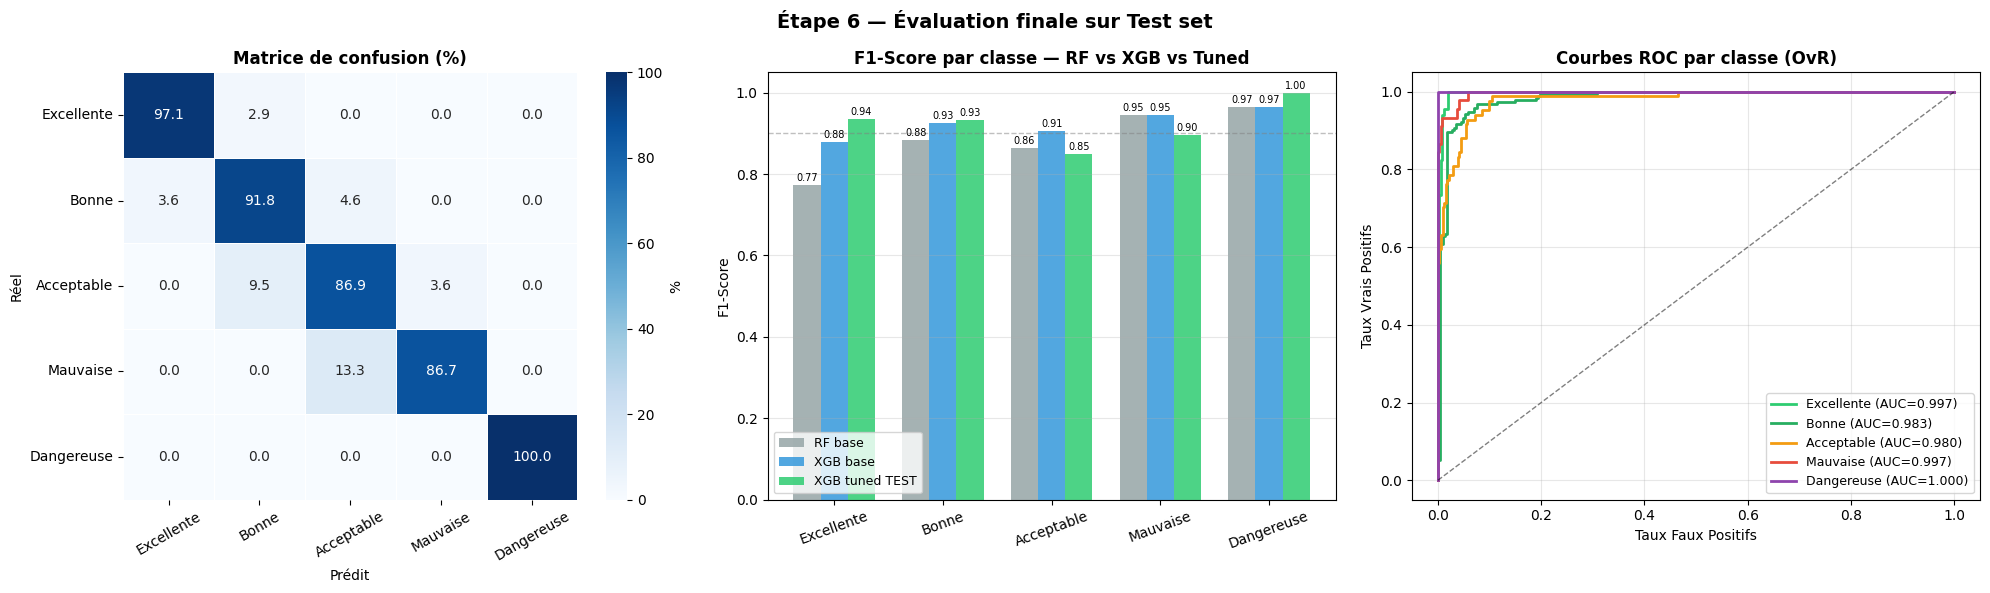


📊 3. BILAN FINAL DU MODÈLE :
   Accuracy Test    : 0.9169
   F1-Macro Test    : 0.9227
   ROC-AUC Test     : 0.9914

   Verdict          : 🟢 EXCELLENT — prêt pour déploiement

 Cellule 5 terminée — Évaluation finale complète
     Prêt pour l'Étape 7 : SHAP Values + Interprétabilité


In [36]:
# Étape 6 — Cellule 5 : Évaluation finale sur Test set

from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

print(" MODÉLISATION — Cellule 5 : Évaluation finale (Test set)")
print("=" * 65)
print("  Le test set n'a JAMAIS été utilisé jusqu'ici — verdict honnête")
print()

# ── Prédictions sur le test set ───────────────────────────────────────────────
y_pred_test  = best_xgb.predict(X_test)
y_proba_test = best_xgb.predict_proba(X_test)

# ── 1. Métriques globales ─────────────────────────────────────────────────────
acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average='macro')
f1_w     = f1_score(y_test, y_pred_test, average='weighted')

print(" 1. MÉTRIQUES GLOBALES (Test set) :")
print("=" * 65)
print(f"   {'Métrique':<25} {'Val':>8}  {'Test':>8}  Δ")
print("   " + "-"*48)
print(f"   {'Accuracy':<25} {acc_val_best:>8.4f}  {acc_test:>8.4f}  "
      f"{acc_test-acc_val_best:+.4f}")
print(f"   {'F1-Macro':<25} {f1_val_best:>8.4f}  {f1_test:>8.4f}  "
      f"{f1_test-f1_val_best:+.4f}")
print(f"   {'F1-Weighted':<25} {'—':>8}  {f1_w:>8.4f}")

# ROC-AUC multiclasse
y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
auc_macro  = roc_auc_score(y_test_bin, y_proba_test,
                            multi_class='ovr', average='macro')
print(f"   {'ROC-AUC (macro OvR)':<25} {'—':>8}  {auc_macro:>8.4f}")

# ── 2. Rapport de classification complet ─────────────────────────────────────
print("\n 2. RAPPORT DE CLASSIFICATION COMPLET :")
print("=" * 65)
target_names = [labels_map[i] for i in range(5)]
print(classification_report(y_test, y_pred_test,
                             target_names=target_names, digits=4))

# ── 3. Visualisations ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Étape 6 — Évaluation finale sur Test set',
             fontsize=14, fontweight='bold')

# ── Graphique 1 : Matrice de confusion ───────────────────────────────────────
ax1 = axes[0]
cm  = confusion_matrix(y_test, y_pred_test)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names,
            linewidths=0.5, ax=ax1, cbar_kws={'label': '%'})
ax1.set_title('Matrice de confusion (%)', fontweight='bold')
ax1.set_xlabel('Prédit')
ax1.set_ylabel('Réel')
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# ── Graphique 2 : F1 par classe comparaison finale ───────────────────────────
ax2 = axes[1]
f1_test_classe = f1_score(y_test, y_pred_test, average=None)
x   = np.arange(5)
w   = 0.25
colors_models = ['#95a5a6', '#3498db', '#2ecc71']

b1 = ax2.bar(x - w, f1_par_classe,      w, label='RF base',      color=colors_models[0], alpha=0.85)
b2 = ax2.bar(x,     f1_par_classe_xgb,  w, label='XGB base',     color=colors_models[1], alpha=0.85)
b3 = ax2.bar(x + w, f1_test_classe,     w, label='XGB tuned TEST', color=colors_models[2], alpha=0.85)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax2.set_xticks(x)
ax2.set_xticklabels(target_names, rotation=20)
ax2.set_ylim(0, 1.05)
ax2.set_title('F1-Score par classe — RF vs XGB vs Tuned', fontweight='bold')
ax2.set_ylabel('F1-Score')
ax2.legend(fontsize=9)
ax2.axhline(0.90, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# ── Graphique 3 : Courbes ROC par classe ─────────────────────────────────────
ax3 = axes[2]
colors_roc = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#8e44ad']

for i, (cls_name, color) in enumerate(zip(target_names, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba_test[:, i])
    ax3.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{cls_name} (AUC={auc_i:.3f})')

ax3.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5)
ax3.set_title('Courbes ROC par classe (OvR)', fontweight='bold')
ax3.set_xlabel('Taux Faux Positifs')
ax3.set_ylabel('Taux Vrais Positifs')
ax3.legend(fontsize=9, loc='lower right')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('etape6_evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Bilan final ────────────────────────────────────────────────────────────
print("\n📊 3. BILAN FINAL DU MODÈLE :")
print("=" * 65)
print(f"   Accuracy Test    : {acc_test:.4f}")
print(f"   F1-Macro Test    : {f1_test:.4f}")
print(f"   ROC-AUC Test     : {auc_macro:.4f}")

if f1_test >= 0.90:
    verdict = "🟢 EXCELLENT — prêt pour déploiement"
elif f1_test >= 0.80:
    verdict = "🟡 BON — acceptable pour production"
else:
    verdict = "🔴 INSUFFISANT — revoir le modèle"
print(f"\n   Verdict          : {verdict}")

print(f"\n Cellule 5 terminée — Évaluation finale complète")
print(f"     Prêt pour l'Étape 7 : SHAP Values + Interprétabilité")

In [37]:
# Étape 6 — Cellule 6 : Sauvegarde du modèle et des artefacts nécessaires

import pickle
import joblib
import json
from datetime import datetime

print("=" * 65)
print("    SAUVEGARDE DU MODÈLE — Déploiement")
print("=" * 65)

# ── 1. Sauvegarde du modèle XGBoost ──────────────────────────────────────────
print("\n 1. Sauvegarde du modèle XGBoost :")

# Méthode 1 : pickle
with open('xgb_water_quality_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)
print("    xgb_water_quality_model.pkl (pickle)")

# Méthode 2 : joblib (recommandé pour scikit-learn/XGBoost)
joblib.dump(best_xgb, 'xgb_water_quality_model.joblib')
print("    xgb_water_quality_model.joblib (joblib)")

# ── 2. Sauvegarde du scaler (pour normalisation) ─────────────────────────────
print("\n 2. Sauvegarde du scaler (MinMaxScaler) :")
with open('scaler_minmax.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("    scaler_minmax.pkl")

# ── 3. Sauvegarde des colonnes features ──────────────────────────────────────
print("\n📌 3. Sauvegarde des métadonnées :")

metadata = {
    'features_finales': features_finales,
    'num_classes': 5,
    'class_mapping': labels_map,
    'model_type': 'XGBoost',
    'target': 'WQI_Class',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance': {
        'accuracy_test': float(acc_test),
        'f1_macro_test': float(f1_test),
        'roc_auc_test': float(auc_macro)
    }
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print("    model_metadata.json")

print("\n RÉCAPITULATIF DES FICHIERS SAUVEGARDÉS :")
print("=" * 65)
print("    xgb_water_quality_model.pkl      → Modèle XGBoost")
print("    xgb_water_quality_model.joblib   → Modèle XGBoost (backup)")
print("    scaler_minmax.pkl                → Normalisation")
print("   model_metadata.json              → Métadonnées (features, classes, perf)")
print("=" * 65)

    SAUVEGARDE DU MODÈLE — Déploiement

 1. Sauvegarde du modèle XGBoost :
    xgb_water_quality_model.pkl (pickle)
    xgb_water_quality_model.joblib (joblib)

 2. Sauvegarde du scaler (MinMaxScaler) :
    scaler_minmax.pkl

📌 3. Sauvegarde des métadonnées :
    model_metadata.json

 RÉCAPITULATIF DES FICHIERS SAUVEGARDÉS :
    xgb_water_quality_model.pkl      → Modèle XGBoost
    xgb_water_quality_model.joblib   → Modèle XGBoost (backup)
    scaler_minmax.pkl                → Normalisation
   model_metadata.json              → Métadonnées (features, classes, perf)


In [38]:
# Étape 6 — Cellule 7 : Téléchargement des fichiers (Kaggle/Colab)

print("=" * 65)
print("    TÉLÉCHARGEMENT DES FICHIERS")
print("=" * 65)

# Détection de l'environnement
try:
    from google.colab import files
    IN_COLAB = True
    print(" Environnement : Google Colab détecté")
except ImportError:
    IN_COLAB = False
    print(" Environnement : Local ou Kaggle")

# Liste des fichiers à télécharger
fichiers_a_telecharger = [
    'xgb_water_quality_model.pkl',
    'xgb_water_quality_model.joblib',
    'scaler_minmax.pkl',
    'model_metadata.json',
    'water_quality_features_scaled.csv',
    'water_quality_clean.csv'
]

# Création d'un fichier ZIP pour faciliter le téléchargement
import zipfile
import os

zip_name = 'water_quality_model_artifacts.zip'
print(f"\n Création de l'archive ZIP : {zip_name}")

with zipfile.ZipFile(zip_name, 'w') as zipf:
    for fichier in fichiers_a_telecharger:
        if os.path.exists(fichier):
            zipf.write(fichier)
            print(f"    Ajout : {fichier}")
        else:
            print(f"    Ignoré (introuvable) : {fichier}")

print(f"\n Archive créée : {zip_name} (taille : {os.path.getsize(zip_name) / 1024:.1f} KB)")

# Téléchargement selon l'environnement
if IN_COLAB:
    print("\n Téléchargement depuis Google Colab :")
    files.download(zip_name)
    print("    Téléchargement déclenché")
else:
    print("\n Pour télécharger les fichiers :")
    print(f"   → Depuis Kaggle : allez dans 'Output' → 'Download all'")
    print(f"   → Depuis terminal : scp {zip_name} user@host:/path/")
    print(f"\n    Fichiers disponibles localement :")
    for f in fichiers_a_telecharger:
        if os.path.exists(f):
            print(f"      - {f}")

print("\n Téléchargement prêt")

    TÉLÉCHARGEMENT DES FICHIERS
 Environnement : Google Colab détecté

 Création de l'archive ZIP : water_quality_model_artifacts.zip
    Ajout : xgb_water_quality_model.pkl
    Ajout : xgb_water_quality_model.joblib
    Ajout : scaler_minmax.pkl
    Ajout : model_metadata.json
    Ajout : water_quality_features_scaled.csv
    Ajout : water_quality_clean.csv

 Archive créée : water_quality_model_artifacts.zip (taille : 3971.3 KB)

 Téléchargement depuis Google Colab :


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

    Téléchargement déclenché

 Téléchargement prêt


In [39]:
# Re-créer le scaler sur les 29 features exactes du modèle
from sklearn.preprocessing import MinMaxScaler
import pickle

# Les 29 features (récupérées depuis les métadonnées ou depuis votre liste)
feature_cols_29 = [
    "DissolvedOxygen (mg/L)", "pH", "WaterTemp (C)", "AirTemp (C)",
    "Log_Salinity", "Log_Secchi", "Log_WaterDepth", "DO_Temp_Ratio",
    "Secchi_Depth_Ratio", "pH_Deviation", "Thermal_Stress", "AirWater_TempDiff",
    "Roll7_DO", "Roll14_DO", "Trend_DO", "Roll7_Temp", "Roll14_Temp",
    "Trend_Temp", "Roll7_pH", "Roll7_Sal", "Month_Sin", "Month_Cos",
    "Saison_Automne", "Saison_Hiver", "Saison_Printemps", "Saison_Été",
    "Zone_enc_Zone_Cotiere", "Zone_enc_Zone_Lagon", "Zone_enc_Zone_Large"
]

# Récupérer les données d'entraînement (X_train) qui ont servi à entraîner le modèle
# Si vous n'avez plus X_train, utilisez df_fe (votre DataFrame final avant split)
# Ici on suppose que vous avez df_fe (avec toutes les features et la cible)
X_full = df_fe[feature_cols_29].values  # ou X_train original

scaler_new = MinMaxScaler()
scaler_new.fit(X_full)

# Sauvegarder le nouveau scaler
with open('scaler_minmax_29.pkl', 'wb') as f:
    pickle.dump(scaler_new, f)

print(" Nouveau scaler (29 features) sauvegardé")

 Nouveau scaler (29 features) sauvegardé
